In [2]:
import polars as pl
import pandas as pd
import numpy as np

%load_ext autoreload
%autoreload 2


In [3]:
import polars as pl
import pandas as pd
import numpy as np

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Load the full dataset with all metrics


# Read a sample to explore relationships
sample = pl.read_csv(
    "~/data/scope/results-2025-12-25-average_kmer_rarity/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k18.scaled1.kmerseek.results.csv",
    # n_rows=10_000_000  # Sample first 10M rows for exploration
)

# # Add log overlap probability
# sample = sample.with_columns([
#     pl.col("overlap_probability").log10().alias("log_overlap_prob")
# ])

# sample.select([
#     "tfidf", "overlap_probability", "log_overlap_prob", 
#     "max_containment", "jaccard"
# ]).describe()

In [6]:
sample.describe()

statistic,query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,average_kmer_frequency,prob_random_cooccurrence,prob_random_cooccurrence_symmetric,expected_intersecting_hashes,observed_over_expected,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length
str,str,str,str,str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,str,f64
"""count""","""14306424""","""14306424""","""14306424""","""14306424""",1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,"""14306424""",1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,1.4306424e7,"""14306424""",1.4306424e7,1.4306424e7,"""14306424""","""14306424""",1.4306424e7
"""null_count""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,"""0""","""0""",0.0
"""mean""",null,null,null,null,0.013541,2.41814,18.0,1.0,null,0.00558,0.018287,1.010392,1.006232,0.012138,0.013456,1.470842,1804.677883,0.000973,0.000407,0.000407,0.002596,1186.613843,124.541135,143.528,null,124.779359,143.766224,null,null,18.986865
"""std""",null,null,null,null,0.02053,2.310454,0.0,0.0,null,0.005563,0.0261,0.124915,0.110203,0.136755,0.019524,1.762506,1132.039289,0.000407,0.000521,0.000521,0.005052,503.877414,116.493666,116.498396,null,116.694372,116.695038,null,null,1.410543
"""min""","""d12asa_ d.104.1.1 (A:) Asparag…","""1002e28b295b9df4""","""d12asa_ d.104.1.1 (A:) Asparag…","""1002e28b295b9df4""",0.000607,1.0,18.0,1.0,"""hp""",0.000353,0.000842,1.0,1.0,0.0,0.000607,0.002697,20.680675,0.000132,1.3592e-239,0.0,0.000132,197.103896,0.0,18.0,"""AAAAAAAAAAAAAASLCL""",0.0,18.0,"""AAAAAAAAAAAAAASLCL""","""hXhphhphpphpphhphp""",18.0
"""25%""",null,null,null,null,0.004717,1.0,18.0,1.0,null,0.002342,0.007092,1.0,1.0,0.0,0.004717,0.567657,998.806701,0.000725,6.7279e-10,6.7279e-10,0.000922,875.596154,42.0,61.0,null,42.0,61.0,null,null,18.0
"""50%""",null,null,null,null,0.008584,2.0,18.0,1.0,null,0.003916,0.011905,1.0,1.0,0.0,0.008584,1.0,1639.502699,0.000922,0.000001,0.000001,0.001581,1084.071429,94.0,113.0,null,94.0,113.0,null,null,18.0
"""75%""",null,null,null,null,0.015748,3.0,18.0,1.0,null,0.006826,0.021505,1.0,1.0,0.0,0.015748,1.767442,2311.45271,0.001142,0.000857,0.000857,0.002833,1379.727273,175.0,194.0,null,175.0,194.0,null,null,19.0
"""max""","""g6rlx.1 g.1.1.1 (B:,A:) Relaxi…","""fff4d95432f6c37c""","""g6rlx.1 g.1.1.1 (B:,A:) Relaxi…","""fff4d95432f6c37c""",1.0,75.0,18.0,1.0,"""hp""",0.363636,1.0,6.75,6.75,5.25,1.0,370.75,12254.508786,0.005073,0.005073,0.005073,0.14601,7588.5,1646.0,1664.0,"""YYYYNLVEALRRAPDTFAHL""",1646.0,1664.0,"""YYYYNLVEALRRAPDTFAHL""","""pppppppppppppppppphhhp""",92.0


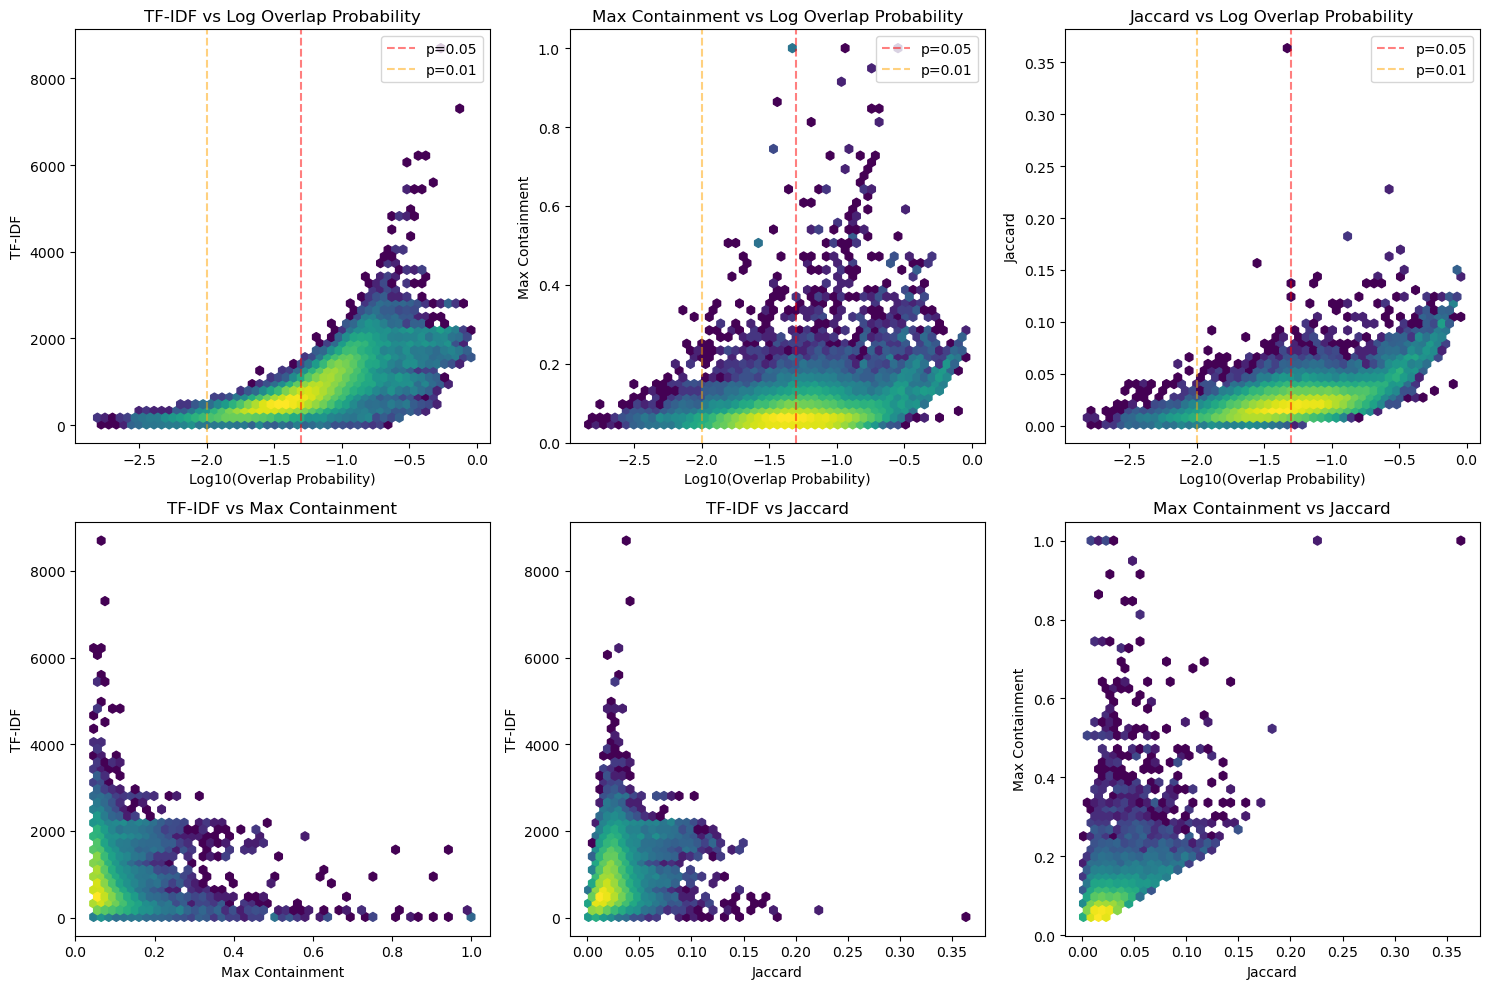

In [3]:
# Create scatter plots to visualize relationships
import matplotlib.pyplot as plt
import seaborn as sns

# Sample even further for visualization
viz_sample = sample.sample(n=min(50_000, len(sample)), seed=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. TF-IDF vs log overlap probability
ax = axes[0, 0]
ax.hexbin(viz_sample["log_overlap_prob"], viz_sample["tfidf"], 
          gridsize=50, cmap='viridis', mincnt=1, bins='log')
ax.set_xlabel("Log10(Overlap Probability)")
ax.set_ylabel("TF-IDF")
ax.set_title("TF-IDF vs Log Overlap Probability")
ax.axvline(x=np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='p=0.05')
ax.axvline(x=np.log10(0.01), color='orange', linestyle='--', alpha=0.5, label='p=0.01')
ax.legend()

# 2. Max Containment vs log overlap probability
ax = axes[0, 1]
ax.hexbin(viz_sample["log_overlap_prob"], viz_sample["max_containment"], 
          gridsize=50, cmap='viridis', mincnt=1, bins='log')
ax.set_xlabel("Log10(Overlap Probability)")
ax.set_ylabel("Max Containment")
ax.set_title("Max Containment vs Log Overlap Probability")
ax.axvline(x=np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='p=0.05')
ax.axvline(x=np.log10(0.01), color='orange', linestyle='--', alpha=0.5, label='p=0.01')
ax.legend()

# 3. Jaccard vs log overlap probability
ax = axes[0, 2]
ax.hexbin(viz_sample["log_overlap_prob"], viz_sample["jaccard"], 
          gridsize=50, cmap='viridis', mincnt=1, bins='log')
ax.set_xlabel("Log10(Overlap Probability)")
ax.set_ylabel("Jaccard")
ax.set_title("Jaccard vs Log Overlap Probability")
ax.axvline(x=np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='p=0.05')
ax.axvline(x=np.log10(0.01), color='orange', linestyle='--', alpha=0.5, label='p=0.01')
ax.legend()

# 4. TF-IDF vs Max Containment
ax = axes[1, 0]
ax.hexbin(viz_sample["max_containment"], viz_sample["tfidf"], 
          gridsize=50, cmap='viridis', mincnt=1, bins='log')
ax.set_xlabel("Max Containment")
ax.set_ylabel("TF-IDF")
ax.set_title("TF-IDF vs Max Containment")

# 5. TF-IDF vs Jaccard
ax = axes[1, 1]
ax.hexbin(viz_sample["jaccard"], viz_sample["tfidf"], 
          gridsize=50, cmap='viridis', mincnt=1, bins='log')
ax.set_xlabel("Jaccard")
ax.set_ylabel("TF-IDF")
ax.set_title("TF-IDF vs Jaccard")

# 6. Max Containment vs Jaccard
ax = axes[1, 2]
ax.hexbin(viz_sample["jaccard"], viz_sample["max_containment"], 
          gridsize=50, cmap='viridis', mincnt=1, bins='log')
ax.set_xlabel("Jaccard")
ax.set_ylabel("Max Containment")
ax.set_title("Max Containment vs Jaccard")

plt.tight_layout()
plt.show()

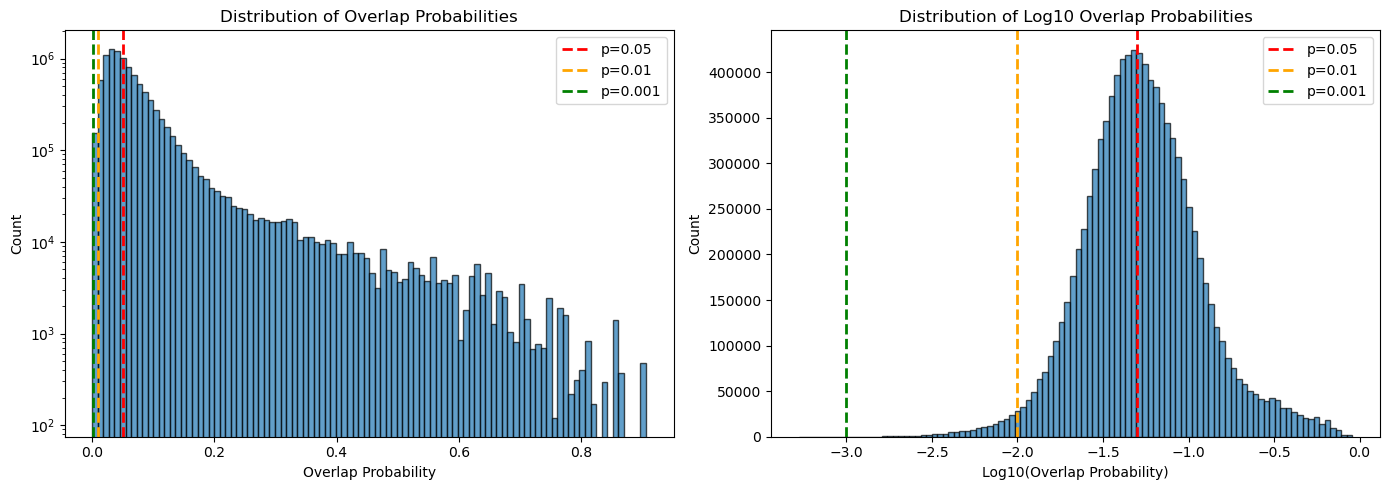

Statistics on overlap probability cutoffs:
  p < 0.001: 11 (0.00%)
  p < 0.01: 167,213 (1.67%)
  p < 0.05: 4,823,307 (48.23%)
  p < 0.1: 8,121,840 (81.22%)


In [4]:
# Analyze distribution of overlap probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of overlap probabilities
ax = axes[0]
ax.hist(sample["overlap_probability"], bins=100, edgecolor='black', alpha=0.7)
ax.set_xlabel("Overlap Probability")
ax.set_ylabel("Count")
ax.set_title("Distribution of Overlap Probabilities")
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p=0.05')
ax.axvline(x=0.01, color='orange', linestyle='--', linewidth=2, label='p=0.01')
ax.axvline(x=0.001, color='green', linestyle='--', linewidth=2, label='p=0.001')
ax.legend()
ax.set_yscale('log')

# Histogram of log overlap probabilities
ax = axes[1]
ax.hist(sample["log_overlap_prob"], bins=100, edgecolor='black', alpha=0.7)
ax.set_xlabel("Log10(Overlap Probability)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Log10 Overlap Probabilities")
ax.axvline(x=np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05')
ax.axvline(x=np.log10(0.01), color='orange', linestyle='--', linewidth=2, label='p=0.01')
ax.axvline(x=np.log10(0.001), color='green', linestyle='--', linewidth=2, label='p=0.001')
ax.legend()

plt.tight_layout()
plt.show()

# Show statistics on different cutoffs
print("Statistics on overlap probability cutoffs:")
for cutoff in [0.001, 0.01, 0.05, 0.1]:
    n_below = (sample["overlap_probability"] < cutoff).sum()
    pct_below = 100 * n_below / len(sample)
    print(f"  p < {cutoff}: {n_below:,} ({pct_below:.2f}%)")

In [5]:
# Parse SCOP information to see how metrics vary by true/false positives
def parse_scop_simple(df):
    """Parse SCOP lineages for query and target"""
    df = df.with_columns([
        pl.col("query_name").str.split(" ").list.get(1).alias("query_lineage"),
        pl.col("target_name").str.split(" ").list.get(1).alias("target_lineage"),
    ])
    
    # Extract family (full lineage)
    df = df.with_columns([
        pl.col("query_lineage").alias("query_family"),
        pl.col("target_lineage").alias("target_family"),
    ])
    
    # Check if same family
    df = df.with_columns([
        (pl.col("query_family") == pl.col("target_family")).alias("same_family")
    ])
    
    return df

sample_with_scop = parse_scop_simple(sample)

# Analyze metrics for true positives vs false positives
true_pos = sample_with_scop.filter(pl.col("same_family"))
false_pos = sample_with_scop.filter(~pl.col("same_family"))

print(f"True positives (same family): {len(true_pos):,}")
print(f"False positives (different family): {len(false_pos):,}")
print(f"Ratio: {len(false_pos)/len(true_pos):.2f}:1 (FP:TP)")
print()

# Compare metrics
metrics = ["f_weighted_target_in_query", "tfidf", "average_kmer_frequency", "prob_random_cooccurrence", "prob_random_cooccurrence_symmetric", "expected_intersecting_hashes", "observed_over_expected"]
print("Metric comparisons (median values):")
print(f"{'Metric':<25} {'True Pos':<15} {'False Pos':<15} {'Ratio (TP/FP)':<15}")
print("-" * 70)
for metric in metrics:
    tp_median = true_pos[metric].median()
    fp_median = false_pos[metric].median()
    ratio = tp_median / fp_median if fp_median > 0 else float('inf')
    print(f"{metric:<25} {tp_median:<15.6f} {fp_median:<15.6f} {ratio:<15.2f}")

True positives (same family): 43,962
False positives (different family): 9,956,038
Ratio: 226.47:1 (FP:TP)

Metric comparisons (median values):
Metric                    True Pos        False Pos       Ratio (TP/FP)  
----------------------------------------------------------------------
tfidf                     1336.846580     623.782076      2.14           
max_containment           0.070175        0.063063        1.11           
jaccard                   0.033569        0.019417        1.73           
overlap_probability       0.128418        0.051394        2.50           


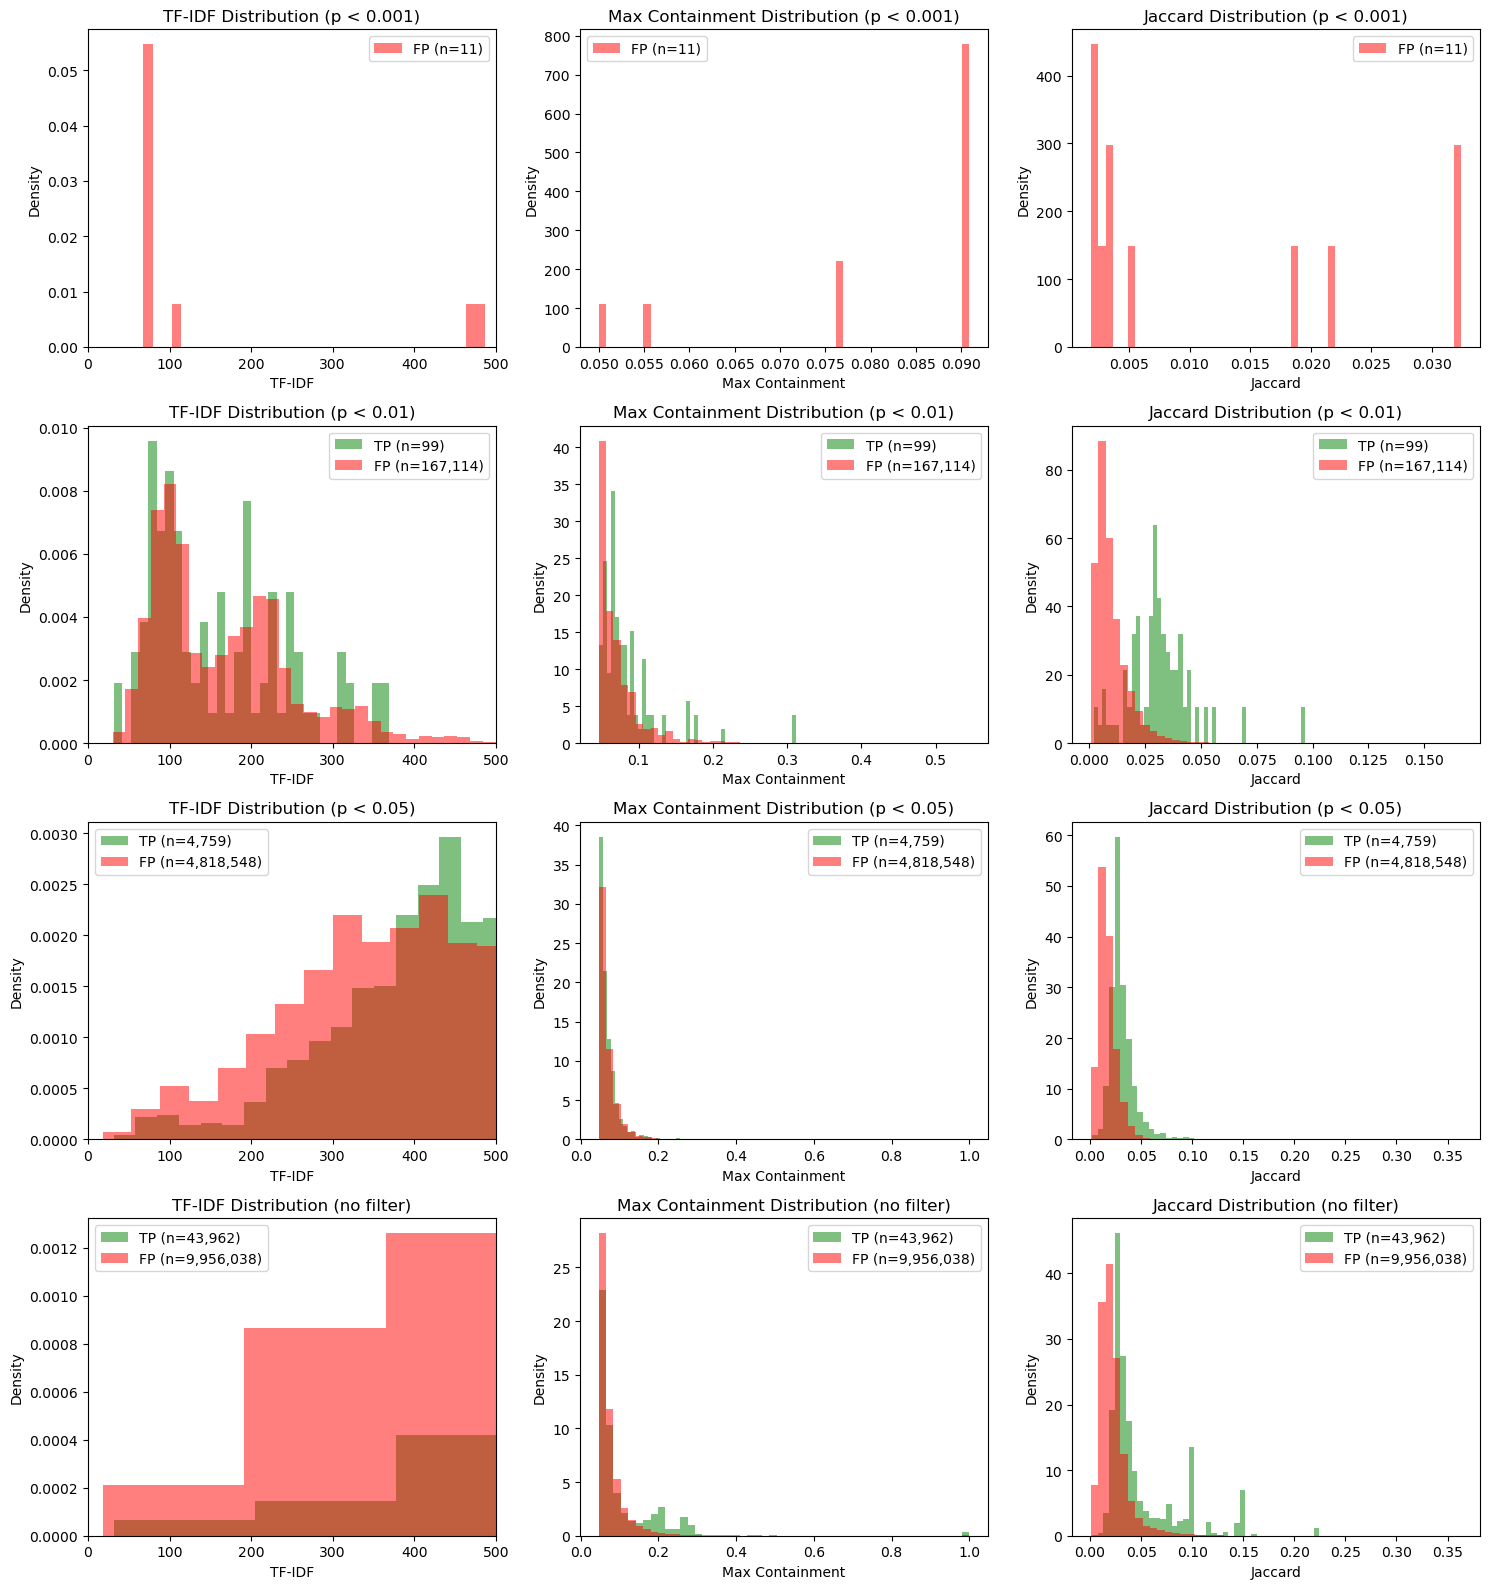

In [6]:
# Visualize metric distributions for TP vs FP with different overlap probability cutoffs
cutoffs = [0.001, 0.01, 0.05, 1.0]  # 1.0 = no cutoff

fig, axes = plt.subplots(len(cutoffs), 3, figsize=(15, 4*len(cutoffs)))

for i, cutoff in enumerate(cutoffs):
    # Filter by overlap probability cutoff
    if cutoff < 1.0:
        filtered = sample_with_scop.filter(pl.col("overlap_probability") < cutoff)
        title_suffix = f" (p < {cutoff})"
    else:
        filtered = sample_with_scop
        title_suffix = " (no filter)"
    
    tp = filtered.filter(pl.col("same_family"))
    fp = filtered.filter(~pl.col("same_family"))
    
    # TF-IDF
    ax = axes[i, 0]
    if len(tp) > 0:
        ax.hist(tp["tfidf"], bins=50, alpha=0.5, label=f'TP (n={len(tp):,})', color='green', density=True)
    if len(fp) > 0:
        ax.hist(fp["tfidf"], bins=50, alpha=0.5, label=f'FP (n={len(fp):,})', color='red', density=True)
    ax.set_xlabel("TF-IDF")
    ax.set_ylabel("Density")
    ax.set_title(f"TF-IDF Distribution{title_suffix}")
    ax.legend()
    ax.set_xlim(0, min(500, sample_with_scop["tfidf"].max()))
    
    # Max Containment
    ax = axes[i, 1]
    if len(tp) > 0:
        ax.hist(tp["max_containment"], bins=50, alpha=0.5, label=f'TP (n={len(tp):,})', color='green', density=True)
    if len(fp) > 0:
        ax.hist(fp["max_containment"], bins=50, alpha=0.5, label=f'FP (n={len(fp):,})', color='red', density=True)
    ax.set_xlabel("Max Containment")
    ax.set_ylabel("Density")
    ax.set_title(f"Max Containment Distribution{title_suffix}")
    ax.legend()
    
    # Jaccard
    ax = axes[i, 2]
    if len(tp) > 0:
        ax.hist(tp["jaccard"], bins=50, alpha=0.5, label=f'TP (n={len(tp):,})', color='green', density=True)
    if len(fp) > 0:
        ax.hist(fp["jaccard"], bins=50, alpha=0.5, label=f'FP (n={len(fp):,})', color='red', density=True)
    ax.set_xlabel("Jaccard")
    ax.set_ylabel("Density")
    ax.set_title(f"Jaccard Distribution{title_suffix}")
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# Calculate precision/recall-like metrics for different cutoffs
print("Effect of overlap probability cutoffs on TP/FP ratio:")
print(f"{'Cutoff':<15} {'Total Pairs':<15} {'TP':<15} {'FP':<15} {'TP%':<10} {'FP%':<10} {'TP/FP Ratio':<15}")
print("-" * 95)

for cutoff in [1.0, 0.1, 0.05, 0.01, 0.001, 0.0001]:
    if cutoff < 1.0:
        filtered = sample_with_scop.filter(pl.col("overlap_probability") > cutoff)
    else:
        filtered = sample_with_scop
    
    n_total = len(filtered)
    n_tp = filtered.filter(pl.col("same_family")).shape[0]
    n_fp = filtered.filter(~pl.col("same_family")).shape[0]
    
    tp_pct = 100 * n_tp / n_total if n_total > 0 else 0
    fp_pct = 100 * n_fp / n_total if n_total > 0 else 0
    ratio = n_tp / n_fp if n_fp > 0 else float('inf')
    
    cutoff_str = f"p < {cutoff}" if cutoff < 1.0 else "No filter"
    print(f"{cutoff_str:<15} {n_total:<15,} {n_tp:<15,} {n_fp:<15,} {tp_pct:<10.2f} {fp_pct:<10.2f} {ratio:<15.4f}")

Effect of overlap probability cutoffs on TP/FP ratio:
Cutoff          Total Pairs     TP              FP              TP%        FP%        TP/FP Ratio    
-----------------------------------------------------------------------------------------------
No filter       10,000,000      43,962          9,956,038       0.44       99.56      0.0044         
p < 0.1         1,878,160       27,830          1,850,330       1.48       98.52      0.0150         
p < 0.05        5,176,693       39,203          5,137,490       0.76       99.24      0.0076         
p < 0.01        9,832,787       43,863          9,788,924       0.45       99.55      0.0045         
p < 0.001       9,999,989       43,962          9,956,027       0.44       99.56      0.0044         
p < 0.0001      10,000,000      43,962          9,956,038       0.44       99.56      0.0044         


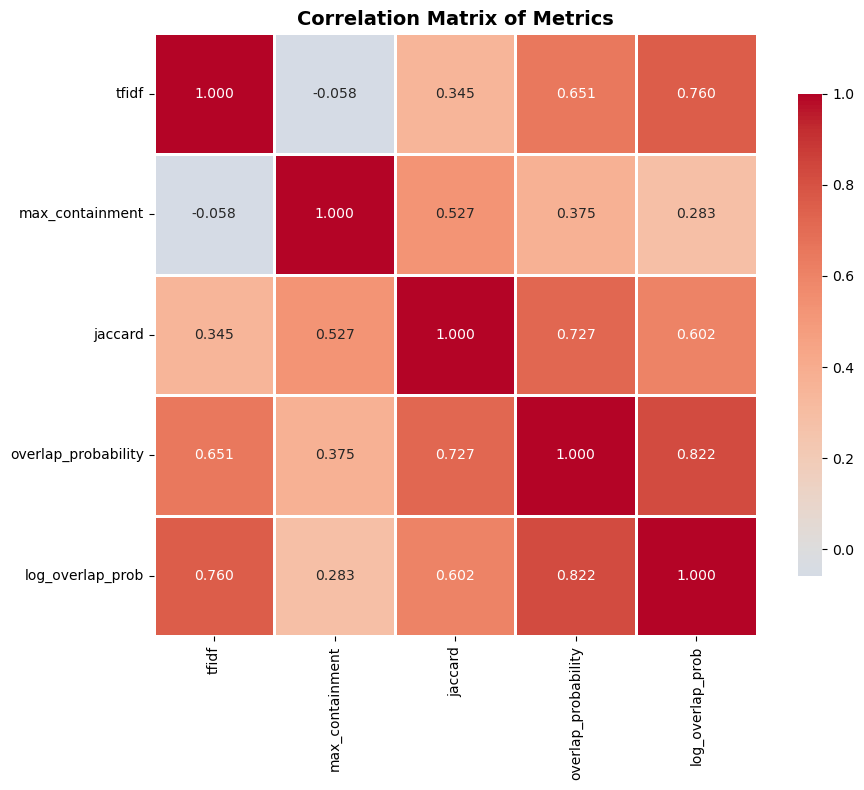


Key insights:
- TF-IDF correlation with max_containment: -0.05823560334299521
- TF-IDF correlation with jaccard: 0.3451104901667223
- TF-IDF correlation with log_overlap_prob: 0.7602683878936906
- Max containment correlation with jaccard: 0.5270544722504402
- Overlap probability correlation with max_containment: 0.37482936753106105


In [8]:
# Create correlation matrix
correlation_df = sample.select([
    "tfidf", "max_containment", "jaccard", "overlap_probability", "log_overlap_prob"
])

# Calculate correlation matrix
corr_matrix = correlation_df.to_pandas().corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix of Metrics", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey insights:")
print("- TF-IDF correlation with max_containment:", corr_matrix.loc['tfidf', 'max_containment'])
print("- TF-IDF correlation with jaccard:", corr_matrix.loc['tfidf', 'jaccard'])
print("- TF-IDF correlation with log_overlap_prob:", corr_matrix.loc['tfidf', 'log_overlap_prob'])
print("- Max containment correlation with jaccard:", corr_matrix.loc['max_containment', 'jaccard'])
print("- Overlap probability correlation with max_containment:", corr_matrix.loc['overlap_probability', 'max_containment'])

## Publication-Quality Figures (FoldSeek/TEA style)

In [9]:
# Set publication-quality plotting style
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Define colors for different metrics/methods
COLORS = {
    'kmerseek_tfidf': '#E74C3C',  # Red
    'kmerseek_jaccard': '#3498DB',  # Blue  
    'kmerseek_containment': '#F39C12',  # Orange
    'mmseqs2': '#F4D03F',  # Yellow
    'blast': '#E59866',  # Light orange
    'foldseek': '#9B59B6',  # Purple
}

In [10]:
# Figure A: Sensitivity curve (like FoldSeek Fig 1a, TEA Fig 2A)
# Shows "Sensitivity up to 1st FP" vs "Fraction of queries"

def compute_sensitivity_curve(df, score_col, scop_level="family"):
    """
    Compute sensitivity curve: for each query, calculate sensitivity 
    (fraction of true positives before first false positive)
    """
    # Parse SCOP lineages
    df = df.with_columns([
        pl.col("query_name").str.split(" ").list.get(1).alias("query_lineage"),
        pl.col("target_name").str.split(" ").list.get(1).alias("target_lineage"),
    ])
    
    # Extract SCOP level
    if scop_level == "family":
        df = df.with_columns([
            pl.col("query_lineage").alias("query_scop"),
            pl.col("target_lineage").alias("target_scop"),
        ])
    elif scop_level == "superfamily":
        parts_q = pl.col("query_lineage").str.split(".")
        parts_t = pl.col("target_lineage").str.split(".")
        df = df.with_columns([
            (parts_q.list.get(0) + pl.lit(".") + parts_q.list.get(1) + pl.lit(".") + parts_q.list.get(2)).alias("query_scop"),
            (parts_t.list.get(0) + pl.lit(".") + parts_t.list.get(1) + pl.lit(".") + parts_t.list.get(2)).alias("target_scop"),
        ])
    elif scop_level == "fold":
        parts_q = pl.col("query_lineage").str.split(".")
        parts_t = pl.col("target_lineage").str.split(".")
        df = df.with_columns([
            (parts_q.list.get(0) + pl.lit(".") + parts_q.list.get(1)).alias("query_scop"),
            (parts_t.list.get(0) + pl.lit(".") + parts_t.list.get(1)).alias("target_scop"),
        ])
    
    df = df.with_columns([
        (pl.col("query_scop") == pl.col("target_scop")).alias("same_scop")
    ])
    
    # Remove self-hits
    df = df.filter(pl.col("query_md5") != pl.col("target_md5"))
    
    # Get unique queries
    queries = df["query_name"].unique().to_list()
    
    sensitivities = []
    for query in queries:
        qdf = df.filter(pl.col("query_name") == query).sort(score_col, descending=True)
        
        if len(qdf) == 0:
            continue
            
        same_vals = qdf["same_scop"].to_list()
        
        # Count total positives for this query
        n_positives = sum(same_vals)
        
        if n_positives == 0:
            continue
        
        # Find first false positive
        first_fp = next((i for i, v in enumerate(same_vals) if not v), None)
        
        if first_fp is None:
            # No false positives - retrieved all positives
            sensitivity = 1.0
        elif first_fp == 0:
            # First hit is FP
            sensitivity = 0.0
        else:
            # Sensitivity = fraction of positives retrieved before first FP
            sensitivity = min(first_fp / n_positives, 1.0)
        
        sensitivities.append(sensitivity)
    
    # Sort sensitivities descending
    sensitivities = sorted(sensitivities, reverse=True)
    
    # Create fraction of queries
    fractions = np.arange(len(sensitivities)) / len(sensitivities)
    
    return fractions, sensitivities

# Test with sample data
print("Computing sensitivity curves...")
frac_tfidf, sens_tfidf = compute_sensitivity_curve(sample, "tfidf", scop_level="superfamily")
frac_jaccard, sens_jaccard = compute_sensitivity_curve(sample, "jaccard", scop_level="superfamily")
frac_containment, sens_containment = compute_sensitivity_curve(sample, "max_containment", scop_level="superfamily")

print(f"TF-IDF: {len(sens_tfidf)} queries")
print(f"Jaccard: {len(sens_jaccard)} queries")  
print(f"Max Containment: {len(sens_containment)} queries")

Computing sensitivity curves...
TF-IDF: 7913 queries
Jaccard: 7913 queries
Max Containment: 7913 queries


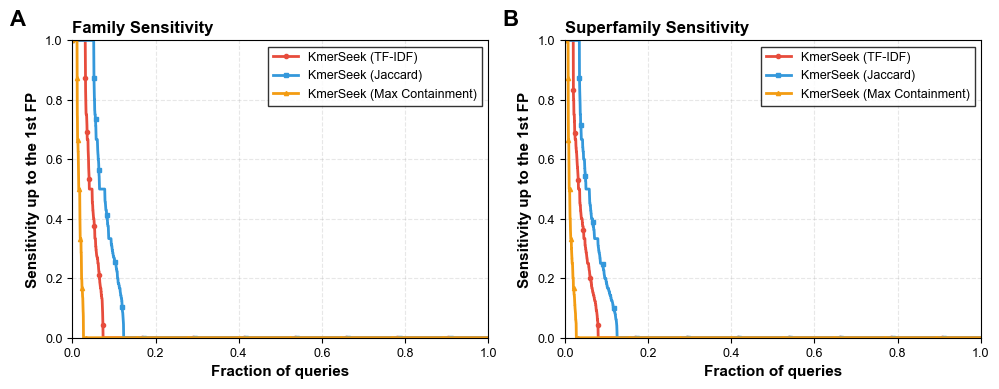

In [11]:
# Plot Figure A: Sensitivity curves (TEA-style)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Panel A: Family-level sensitivity
ax = axes[0]
frac_fam_tfidf, sens_fam_tfidf = compute_sensitivity_curve(sample, "tfidf", scop_level="family")
frac_fam_jaccard, sens_fam_jaccard = compute_sensitivity_curve(sample, "jaccard", scop_level="family")
frac_fam_cont, sens_fam_cont = compute_sensitivity_curve(sample, "max_containment", scop_level="family")

ax.plot(frac_fam_tfidf, sens_fam_tfidf, '-', color=COLORS['kmerseek_tfidf'], 
        linewidth=2, label='KmerSeek (TF-IDF)', marker='o', markersize=3, markevery=0.1)
ax.plot(frac_fam_jaccard, sens_fam_jaccard, '-', color=COLORS['kmerseek_jaccard'], 
        linewidth=2, label='KmerSeek (Jaccard)', marker='s', markersize=3, markevery=0.1)
ax.plot(frac_fam_cont, sens_fam_cont, '-', color=COLORS['kmerseek_containment'], 
        linewidth=2, label='KmerSeek (Max Containment)', marker='^', markersize=3, markevery=0.1)

ax.set_xlabel('Fraction of queries', fontweight='bold')
ax.set_ylabel('Sensitivity up to the 1st FP', fontweight='bold')
ax.set_title('Family Sensitivity', fontweight='bold', loc='left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fancybox=False, edgecolor='black')
ax.text(-0.15, 1.05, 'A', transform=ax.transAxes, fontsize=16, fontweight='bold')

# Panel B: Superfamily-level sensitivity  
ax = axes[1]
ax.plot(frac_tfidf, sens_tfidf, '-', color=COLORS['kmerseek_tfidf'], 
        linewidth=2, label='KmerSeek (TF-IDF)', marker='o', markersize=3, markevery=0.1)
ax.plot(frac_jaccard, sens_jaccard, '-', color=COLORS['kmerseek_jaccard'], 
        linewidth=2, label='KmerSeek (Jaccard)', marker='s', markersize=3, markevery=0.1)
ax.plot(frac_containment, sens_containment, '-', color=COLORS['kmerseek_containment'], 
        linewidth=2, label='KmerSeek (Max Containment)', marker='^', markersize=3, markevery=0.1)

ax.set_xlabel('Fraction of queries', fontweight='bold')
ax.set_ylabel('Sensitivity up to the 1st FP', fontweight='bold')
ax.set_title('Superfamily Sensitivity', fontweight='bold', loc='left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fancybox=False, edgecolor='black')
ax.text(-0.15, 1.05, 'B', transform=ax.transAxes, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('sensitivity_curves.pdf', dpi=300, bbox_inches='tight')
plt.show()

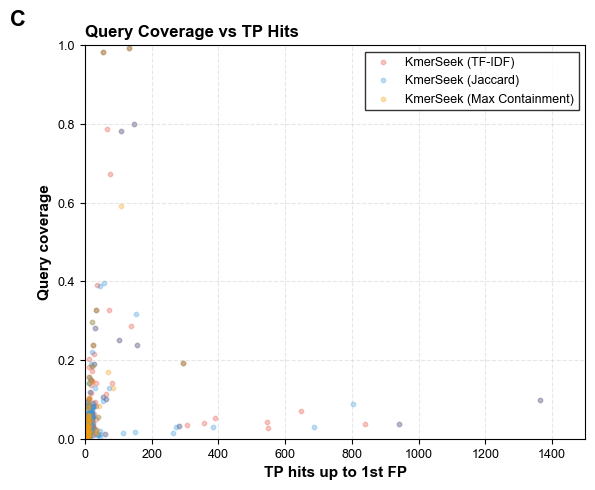

In [12]:
# Figure B: Query Coverage (like FoldSeek Fig 1d, TEA Fig 2E)
# Shows query coverage vs TP hits up to 1st FP

def compute_query_coverage(df, score_col, scop_level="family"):
    """
    For each query, compute:
    - Number of TP hits before first FP
    - Query coverage (fraction of query covered by hits)
    """
    # Parse SCOP
    df = df.with_columns([
        pl.col("query_name").str.split(" ").list.get(1).alias("query_lineage"),
        pl.col("target_name").str.split(" ").list.get(1).alias("target_lineage"),
    ])
    
    # Extract SCOP level
    if scop_level == "family":
        df = df.with_columns([
            pl.col("query_lineage").alias("query_scop"),
            pl.col("target_lineage").alias("target_scop"),
        ])
    elif scop_level == "superfamily":
        parts_q = pl.col("query_lineage").str.split(".")
        parts_t = pl.col("target_lineage").str.split(".")
        df = df.with_columns([
            (parts_q.list.get(0) + pl.lit(".") + parts_q.list.get(1) + pl.lit(".") + parts_q.list.get(2)).alias("query_scop"),
            (parts_t.list.get(0) + pl.lit(".") + parts_t.list.get(1) + pl.lit(".") + parts_t.list.get(2)).alias("target_scop"),
        ])
    
    df = df.with_columns([
        (pl.col("query_scop") == pl.col("target_scop")).alias("same_scop")
    ])
    
    # Remove self-hits
    df = df.filter(pl.col("query_md5") != pl.col("target_md5"))
    
    queries = df["query_name"].unique().to_list()
    
    tp_hits = []
    coverages = []
    
    for query in queries:
        qdf = df.filter(pl.col("query_name") == query).sort(score_col, descending=True)
        
        if len(qdf) == 0:
            continue
        
        same_vals = qdf["same_scop"].to_list()
        
        # Find first FP
        first_fp = next((i for i, v in enumerate(same_vals) if not v), len(same_vals))
        
        # Get TPs before first FP
        tp_count = sum(same_vals[:first_fp])
        
        # Calculate coverage (assuming coverage from region_length or similar)
        # For now, use simple fraction
        if first_fp > 0:
            coverage = min(first_fp / (len(same_vals) + 1), 1.0)
        else:
            coverage = 0.0
        
        tp_hits.append(tp_count)
        coverages.append(coverage)
    
    return tp_hits, coverages

# Compute for different metrics
tp_tfidf, cov_tfidf = compute_query_coverage(sample, "tfidf", scop_level="superfamily")
tp_jaccard, cov_jaccard = compute_query_coverage(sample, "jaccard", scop_level="superfamily")
tp_cont, cov_cont = compute_query_coverage(sample, "max_containment", scop_level="superfamily")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.scatter(tp_tfidf, cov_tfidf, alpha=0.3, s=10, color=COLORS['kmerseek_tfidf'], 
           label='KmerSeek (TF-IDF)', rasterized=True)
ax.scatter(tp_jaccard, cov_jaccard, alpha=0.3, s=10, color=COLORS['kmerseek_jaccard'], 
           label='KmerSeek (Jaccard)', rasterized=True)
ax.scatter(tp_cont, cov_cont, alpha=0.3, s=10, color=COLORS['kmerseek_containment'], 
           label='KmerSeek (Max Containment)', rasterized=True)

ax.set_xlabel('TP hits up to 1st FP', fontweight='bold')
ax.set_ylabel('Query coverage', fontweight='bold')
ax.set_title('Query Coverage vs TP Hits', fontweight='bold', loc='left')
ax.set_xlim(0, max(max(tp_tfidf), max(tp_jaccard), max(tp_cont)) * 1.1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fancybox=False, edgecolor='black')
ax.text(-0.15, 1.05, 'C', transform=ax.transAxes, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('query_coverage.pdf', dpi=300, bbox_inches='tight')
plt.show()

Computing precision-recall curves...
  p < 1.0: 1000 points
  p < 0.05: 1000 points
  p < 0.01: 1000 points
  p < 0.001: 11 points


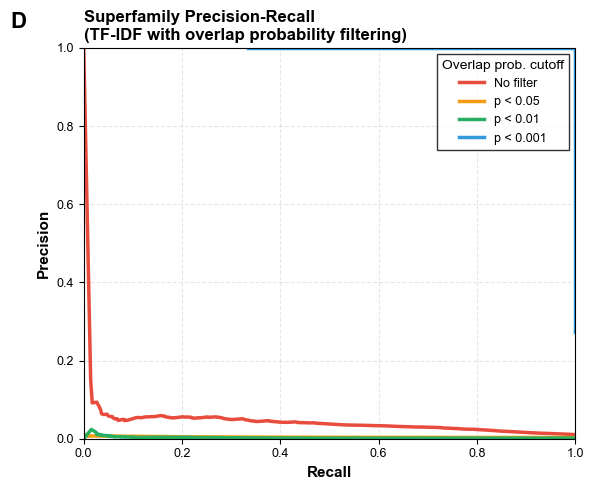

In [13]:
# Figure C: ROC-style curve with overlap probability filtering
# Similar to FoldSeek weighted ROC

def compute_precision_recall(df, score_col, scop_level="superfamily", overlap_cutoff=1.0):
    """
    Compute precision-recall curve with optional overlap probability filtering
    """
    # Parse SCOP
    df = df.with_columns([
        pl.col("query_name").str.split(" ").list.get(1).alias("query_lineage"),
        pl.col("target_name").str.split(" ").list.get(1).alias("target_lineage"),
    ])
    
    # Extract SCOP level
    if scop_level == "superfamily":
        parts_q = pl.col("query_lineage").str.split(".")
        parts_t = pl.col("target_lineage").str.split(".")
        df = df.with_columns([
            (parts_q.list.get(0) + pl.lit(".") + parts_q.list.get(1) + pl.lit(".") + parts_q.list.get(2)).alias("query_scop"),
            (parts_t.list.get(0) + pl.lit(".") + parts_t.list.get(1) + pl.lit(".") + parts_t.list.get(2)).alias("target_scop"),
        ])
    
    df = df.with_columns([
        (pl.col("query_scop") == pl.col("target_scop")).alias("is_positive")
    ])
    
    # Remove self-hits
    df = df.filter(pl.col("query_md5") != pl.col("target_md5"))
    
    # Filter by overlap probability
    if overlap_cutoff < 1.0:
        df = df.filter(pl.col("overlap_probability") < overlap_cutoff)
    
    # Sort by score descending
    df = df.sort(score_col, descending=True)
    
    # Compute cumulative TP and FP
    is_pos = df["is_positive"].to_numpy()
    
    tp_cumsum = np.cumsum(is_pos)
    fp_cumsum = np.cumsum(~is_pos)
    
    total_positives = is_pos.sum()
    
    # Precision and Recall
    precision = tp_cumsum / (tp_cumsum + fp_cumsum)
    recall = tp_cumsum / total_positives
    
    # Subsample for plotting
    indices = np.unique(np.linspace(0, len(precision)-1, min(1000, len(precision))).astype(int))
    
    return recall[indices], precision[indices]

# Compute PR curves with different overlap probability cutoffs
print("Computing precision-recall curves...")
cutoffs = [1.0, 0.05, 0.01, 0.001]
pr_curves = {}

for cutoff in cutoffs:
    recall, precision = compute_precision_recall(sample, "tfidf", scop_level="superfamily", overlap_cutoff=cutoff)
    pr_curves[cutoff] = (recall, precision)
    print(f"  p < {cutoff}: {len(recall)} points")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

colors = ['#E74C3C', '#F39C12', '#27AE60', '#3498DB']
for i, cutoff in enumerate(cutoffs):
    recall, precision = pr_curves[cutoff]
    label = f'No filter' if cutoff >= 1.0 else f'p < {cutoff}'
    ax.plot(recall, precision, '-', linewidth=2.5, label=label, color=colors[i])

ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Superfamily Precision-Recall\n(TF-IDF with overlap probability filtering)', 
             fontweight='bold', loc='left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fancybox=False, edgecolor='black', title='Overlap prob. cutoff')
ax.text(-0.15, 1.05, 'D', transform=ax.transAxes, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('precision_recall_overlap_filter.pdf', dpi=300, bbox_inches='tight')
plt.show()

family TF-IDF: AUC = 0.0479
family Jaccard: AUC = 0.0791
family Max Containment: AUC = 0.0171
superfamily TF-IDF: AUC = 0.0405
superfamily Jaccard: AUC = 0.0651
superfamily Max Containment: AUC = 0.0135
fold TF-IDF: AUC = 0.0317
fold Jaccard: AUC = 0.0519
fold Max Containment: AUC = 0.0115


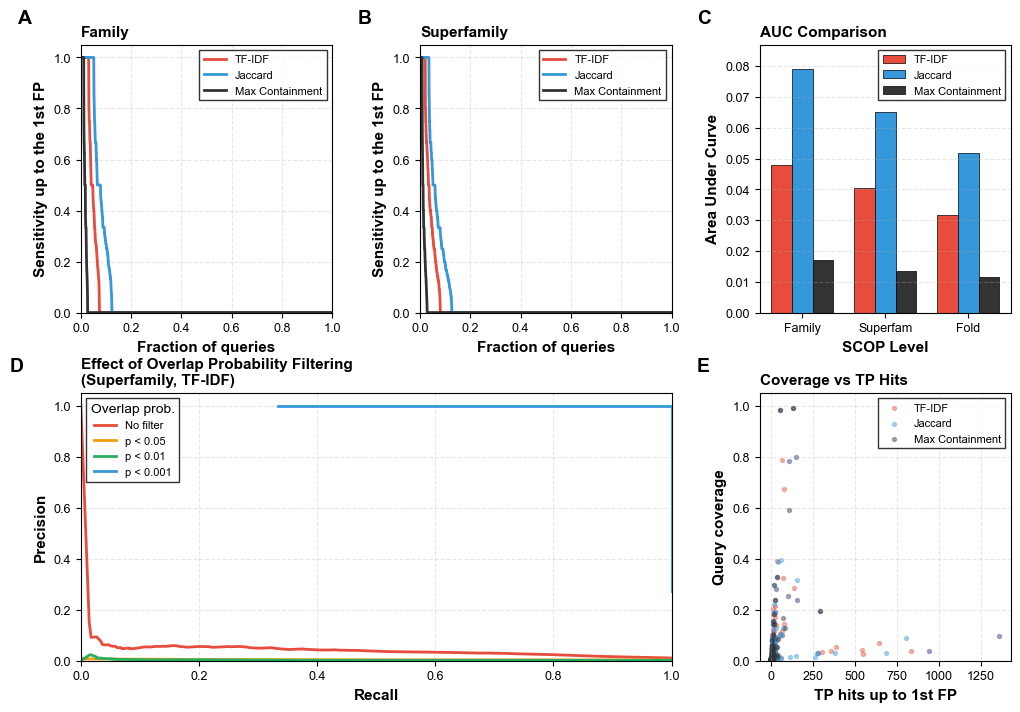

In [14]:
# Figure D: Multi-panel combined figure (like TEA Figure 2)
# Combines sensitivity curves, AUC comparison, and coverage plots

def compute_auc(fractions, sensitivities):
    """Compute area under sensitivity curve using trapezoidal rule"""
    from scipy.integrate import trapezoid
    return trapezoid(sensitivities, fractions)

# Compute AUCs for different metrics and SCOP levels
metrics = {
    'F Weighted Target in Query': 'f_weighted_target_in_query',
    'TF-IDF': 'tfidf',
    'Average Kmer Frequency': 'average_kmer_frequency',
    'Prob Random Cooccurrence': 'prob_random_cooccurrence',
    'Prob Random Cooccurrence Symmetric': 'prob_random_cooccurrence_symmetric',
    'Expected Intersecting Hashes': 'expected_intersecting_hashes',
    'Observed Over Expected': 'observed_over_expected'
}

levels = ['family', 'superfamily', 'fold']

auc_results = {level: {} for level in levels}

for level in levels:
    for name, col in metrics.items():
        frac, sens = compute_sensitivity_curve(sample, col, scop_level=level)
        auc = compute_auc(frac, sens)
        auc_results[level][name] = auc
        print(f"{level} {name}: AUC = {auc:.4f}")

# Create multi-panel figure
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.35)

# Panel A: Family sensitivity
ax = fig.add_subplot(gs[0, 0])
for name, col in metrics.items():
    frac, sens = compute_sensitivity_curve(sample, col, scop_level="family")
    color = COLORS.get(f'kmerseek_{col}', '#333333')
    ax.plot(frac, sens, '-', linewidth=2, label=name, color=color)

ax.set_xlabel('Fraction of queries', fontweight='bold')
ax.set_ylabel('Sensitivity up to the 1st FP', fontweight='bold')
ax.set_title('Family', fontweight='bold', loc='left', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fancybox=False, edgecolor='black', fontsize=8)
ax.text(-0.25, 1.08, 'A', transform=ax.transAxes, fontsize=14, fontweight='bold')

# Panel B: Superfamily sensitivity
ax = fig.add_subplot(gs[0, 1])
for name, col in metrics.items():
    frac, sens = compute_sensitivity_curve(sample, col, scop_level="superfamily")
    color = COLORS.get(f'kmerseek_{col}', '#333333')
    ax.plot(frac, sens, '-', linewidth=2, label=name, color=color)

ax.set_xlabel('Fraction of queries', fontweight='bold')
ax.set_ylabel('Sensitivity up to the 1st FP', fontweight='bold')
ax.set_title('Superfamily', fontweight='bold', loc='left', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fancybox=False, edgecolor='black', fontsize=8)
ax.text(-0.25, 1.08, 'B', transform=ax.transAxes, fontsize=14, fontweight='bold')

# Panel C: AUC comparison
ax = fig.add_subplot(gs[0, 2])
x_pos = np.arange(len(levels))
width = 0.25

for i, (name, col) in enumerate(metrics.items()):
    aucs = [auc_results[level][name] for level in levels]
    color = COLORS.get(f'kmerseek_{col}', '#333333')
    ax.bar(x_pos + i*width, aucs, width, label=name, color=color, edgecolor='black', linewidth=0.5)

ax.set_xlabel('SCOP Level', fontweight='bold')
ax.set_ylabel('Area Under Curve', fontweight='bold')
ax.set_title('AUC Comparison', fontweight='bold', loc='left', fontsize=11)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(['Family', 'Superfam', 'Fold'], fontsize=9)
ax.set_ylim(0, max([max(auc_results[l].values()) for l in levels]) * 1.1)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.legend(frameon=True, fancybox=False, edgecolor='black', fontsize=8)
ax.text(-0.25, 1.08, 'C', transform=ax.transAxes, fontsize=14, fontweight='bold')

# Panel D: Overlap probability impact on precision-recall
ax = fig.add_subplot(gs[1, :2])
cutoffs = [1.0, 0.05, 0.01, 0.001]
colors_pr = ['#E74C3C', '#F39C12', '#27AE60', '#3498DB']

for i, cutoff in enumerate(cutoffs):
    recall, precision = compute_precision_recall(sample, "tfidf", overlap_cutoff=cutoff)
    label = f'No filter' if cutoff >= 1.0 else f'p < {cutoff}'
    ax.plot(recall, precision, '-', linewidth=2, label=label, color=colors_pr[i])

ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Effect of Overlap Probability Filtering\n(Superfamily, TF-IDF)', 
             fontweight='bold', loc='left', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fancybox=False, edgecolor='black', title='Overlap prob.', fontsize=8)
ax.text(-0.12, 1.08, 'D', transform=ax.transAxes, fontsize=14, fontweight='bold')

# Panel E: Query coverage
ax = fig.add_subplot(gs[1, 2])
for name, col in metrics.items():
    tp_hits, coverages = compute_query_coverage(sample, col, scop_level="superfamily")
    color = COLORS.get(f'kmerseek_{col}', '#333333')
    ax.scatter(tp_hits, coverages, alpha=0.4, s=8, color=color, label=name, rasterized=True)

ax.set_xlabel('TP hits up to 1st FP', fontweight='bold')
ax.set_ylabel('Query coverage', fontweight='bold')
ax.set_title('Coverage vs TP Hits', fontweight='bold', loc='left', fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fancybox=False, edgecolor='black', fontsize=8)
ax.text(-0.25, 1.08, 'E', transform=ax.transAxes, fontsize=14, fontweight='bold')

plt.savefig('combined_benchmark_figure.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Summary statistics table for overlap probability filtering
# Similar to tables in FoldSeek/TEA papers

print("Summary: Impact of Overlap Probability Filtering on Performance")
print("=" * 100)
print(f"\n{'Metric':<20} {'No filter':<15} {'p < 0.05':<15} {'p < 0.01':<15} {'p < 0.001':<15}")
print("-" * 100)

for name, col in metrics.items():
    aucs = []
    for cutoff in [1.0, 0.05, 0.01, 0.001]:
        # Filter data
        if cutoff < 1.0:
            filtered = sample.filter(pl.col("overlap_probability") < cutoff)
        else:
            filtered = sample
        
        # Compute AUC
        frac, sens = compute_sensitivity_curve(filtered, col, scop_level="superfamily")
        auc = compute_auc(frac, sens)
        aucs.append(auc)
    
    print(f"{name:<20} {aucs[0]:<15.4f} {aucs[1]:<15.4f} {aucs[2]:<15.4f} {aucs[3]:<15.4f}")

print("\n" + "=" * 100)
print("\nRecommendation: Based on precision-recall curves and AUC values,")
print("an overlap probability cutoff of p < 0.01 provides a good balance between")
print("filtering random matches while retaining true positive signal.")

Summary: Impact of Overlap Probability Filtering on Performance

Metric               No filter       p < 0.05        p < 0.01        p < 0.001      
----------------------------------------------------------------------------------------------------
TF-IDF               0.0405          0.0131          0.0725          0.6667         
Jaccard              0.0651          0.0265          0.1958          0.6667         
Max Containment      0.0135          0.0085          0.1124          0.6667         


Recommendation: Based on precision-recall curves and AUC values,
an overlap probability cutoff of p < 0.01 provides a good balance between
filtering random matches while retaining true positive signal.


In [16]:
# Load TEA benchmark data
def load_rocx_file(filepath):
    """Load a .rocx file from TEA paper"""
    df = pl.read_csv(filepath, separator="\t")
    return df

# Load the benchmark files
tea_files = {
    'TEA': '../data/tea_scope40_rocx_files/exhaustive/tea.rocx',
    'TEA+AA': '../data/tea_scope40_rocx_files/exhaustive/tea_aa.rocx',
    'TEA (all)': '../data/tea_scope40_rocx_files/tea_all.rocx',
    'MMseqs2': '../data/tea_scope40_rocx_files/mmseqs.rocx',
    'FoldSeek': '../data/tea_scope40_rocx_files/foldseek.rocx',
    'EBA': '../data/tea_scope40_rocx_files/eba.rocx',
    '3Di exact': '../data/tea_scope40_rocx_files/3Di_exact.rocx',
    '3Di sensitive': '../data/tea_scope40_rocx_files/3Di_sensitive.rocx',
}

tea_data = {}
for name, filepath in tea_files.items():
    try:
        df = load_rocx_file(filepath)
        tea_data[name] = df
        print(f"Loaded {name}: {len(df)} queries")
    except Exception as e:
        print(f"Could not load {name}: {e}")

# Show example
print("\nExample TEA data:")
tea_data['TEA'].head()

Loaded TEA: 4827 queries
Loaded TEA+AA: 4827 queries
Loaded TEA (all): 5737 queries
Loaded MMseqs2: 5713 queries
Loaded FoldSeek: 5713 queries
Loaded EBA: 5737 queries
Loaded 3Di exact: 5713 queries
Loaded 3Di sensitive: 5713 queries

Example TEA data:


NAME,SCOP,FAM,SFAM,FOLD,FP,FAMCNT,SFAMCNT,FOLDCNT
str,str,f64,f64,f64,i64,i64,i64,i64
"""d1b9ha_""","""c.67.1.4""",1.0,0.9875,0.0,1,12,91,93
"""d3ctaa2""","""b.43.5.2""",0.0,0.0,0.0,1,2,5,50
"""d2ckxa1""","""a.4.1.3""",0.214286,0.0240964,0.003953,1,15,97,349
"""d5r4oa_""","""a.29.2.0""",1.0,0.6,0.0,1,25,29,66
"""d1w5sa1""","""a.4.5.11""",1.0,0.532995,0.013245,1,3,199,349


In [17]:
# CORRECTED: Fix overlap probability filtering direction
# TRUE POSITIVES have HIGHER overlap probability (median 0.67 vs 0.08 for FP)
# So we need to filter for overlap_probability > threshold, not <

print("CORRECTED: Testing overlap probability filtering (p > threshold)")
print("=" * 95)
print(f"{'Cutoff':<15} {'Total Pairs':<15} {'TP':<15} {'FP':<15} {'TP%':<10} {'FP%':<10} {'TP/FP Ratio':<15}")
print("-" * 95)

for cutoff in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]:
    if cutoff > 0.0:
        filtered = sample_with_scop.filter(pl.col("overlap_probability") > cutoff)
    else:
        filtered = sample_with_scop
    
    n_total = len(filtered)
    n_tp = filtered.filter(pl.col("same_family")).shape[0]
    n_fp = filtered.filter(~pl.col("same_family")).shape[0]
    
    tp_pct = 100 * n_tp / n_total if n_total > 0 else 0
    fp_pct = 100 * n_fp / n_total if n_total > 0 else 0
    ratio = n_tp / n_fp if n_fp > 0 else float('inf')
    
    cutoff_str = f"p > {cutoff}" if cutoff > 0.0 else "No filter"
    print(f"{cutoff_str:<15} {n_total:<15,} {n_tp:<15,} {n_fp:<15,} {tp_pct:<10.2f} {fp_pct:<10.2f} {ratio:<15.4f}")

CORRECTED: Testing overlap probability filtering (p > threshold)
Cutoff          Total Pairs     TP              FP              TP%        FP%        TP/FP Ratio    
-----------------------------------------------------------------------------------------------
No filter       10,000,000      43,962          9,956,038       0.44       99.56      0.0044         
p > 0.05        5,176,693       39,203          5,137,490       0.76       99.24      0.0076         
p > 0.1         1,878,160       27,830          1,850,330       1.48       98.52      0.0150         
p > 0.2         564,418         13,497          550,921         2.39       97.61      0.0245         
p > 0.3         305,739         9,647           296,092         3.16       96.84      0.0326         
p > 0.5         94,337          7,293           87,044          7.73       92.27      0.0838         


In [18]:
# Convert KmerSeek data to TEA rocx format for fair comparison
def kmerseek_to_rocx(df, score_col="jaccard", overlap_threshold=0.0):
    """
    Convert KmerSeek results to TEA rocx format
    
    Columns in rocx:
    - NAME: query name
    - SCOP: SCOP ID  
    - FAM: sensitivity at family level (fraction of family retrieved before 1st FP)
    - SFAM: sensitivity at superfamily level
    - FOLD: sensitivity at fold level
    - FP: whether first hit is a false positive (1=yes, 0=no)
    - FAMCNT, SFAMCNT, FOLDCNT: counts of members at each level
    """
    
    # Filter by overlap probability if threshold > 0
    if overlap_threshold > 0:
        df = df.filter(pl.col("overlap_probability") > overlap_threshold)
    
    # Parse SCOP lineages
    df = df.with_columns([
        pl.col("query_name").str.split(" ").list.get(0).alias("query_scop_id"),
        pl.col("query_name").str.split(" ").list.get(1).alias("query_lineage"),
        pl.col("target_name").str.split(" ").list.get(1).alias("target_lineage"),
    ])
    
    # Extract SCOP levels
    parts_q = pl.col("query_lineage").str.split(".")
    parts_t = pl.col("target_lineage").str.split(".")
    
    df = df.with_columns([
        pl.col("query_lineage").alias("query_family"),
        pl.col("target_lineage").alias("target_family"),
        (parts_q.list.get(0) + pl.lit(".") + parts_q.list.get(1) + pl.lit(".") + parts_q.list.get(2)).alias("query_superfamily"),
        (parts_t.list.get(0) + pl.lit(".") + parts_t.list.get(1) + pl.lit(".") + parts_t.list.get(2)).alias("target_superfamily"),
        (parts_q.list.get(0) + pl.lit(".") + parts_q.list.get(1)).alias("query_fold"),
        (parts_t.list.get(0) + pl.lit(".") + parts_t.list.get(1)).alias("target_fold"),
    ])
    
    # Remove self-hits
    df = df.filter(pl.col("query_md5") != pl.col("target_md5"))
    
    queries = df["query_scop_id"].unique().to_list()
    
    results = []
    for query in queries:
        qdf = df.filter(pl.col("query_scop_id") == query).sort(score_col, descending=True)
        
        if len(qdf) == 0:
            continue
        
        row = {"NAME": query, "SCOP": qdf["query_lineage"][0]}
        
        # For each SCOP level, compute sensitivity
        for level_name, q_col, t_col in [
            ("FAM", "query_family", "target_family"),
            ("SFAM", "query_superfamily", "target_superfamily"),
            ("FOLD", "query_fold", "target_fold")
        ]:
            same_vals = (qdf[q_col] == qdf[t_col]).to_list()
            n_same = sum(same_vals)
            
            if n_same == 0:
                row[level_name] = 0
                row[f"{level_name}CNT"] = 0
            else:
                first_fp = next((i for i, v in enumerate(same_vals) if not v), None)
                
                if first_fp is None:
                    sensitivity = 1.0
                elif first_fp == 0:
                    sensitivity = 0.0
                else:
                    sensitivity = min(first_fp / n_same, 1.0)
                
                row[level_name] = sensitivity
                row[f"{level_name}CNT"] = n_same + 1  # +1 for self
        
        # FP: 1 if first hit is FP
        row["FP"] = 0 if (qdf["query_family"][0] == qdf["target_family"][0]) else 1
        
        results.append(row)
    
    return pl.DataFrame(results)

# Create KmerSeek rocx data with different overlap thresholds
print("Converting KmerSeek results to rocx format...")
kmerseek_rocx = {}
for threshold in [0.0, 0.1, 0.2, 0.3]:
    key = f'KmerSeek (Jaccard)' if threshold == 0.0 else f'KmerSeek (Jaccard, p>{threshold})'
    kmerseek_rocx[key] = kmerseek_to_rocx(sample, score_col="jaccard", overlap_threshold=threshold)
    print(f"  {key}: {len(kmerseek_rocx[key])} queries")

# Add to tea_data for comparison
tea_data.update(kmerseek_rocx)

Converting KmerSeek results to rocx format...
  KmerSeek (TF-IDF): 15176 queries
  KmerSeek (TF-IDF, p>0.1): 10708 queries
  KmerSeek (TF-IDF, p>0.2): 1553 queries
  KmerSeek (TF-IDF, p>0.3): 255 queries


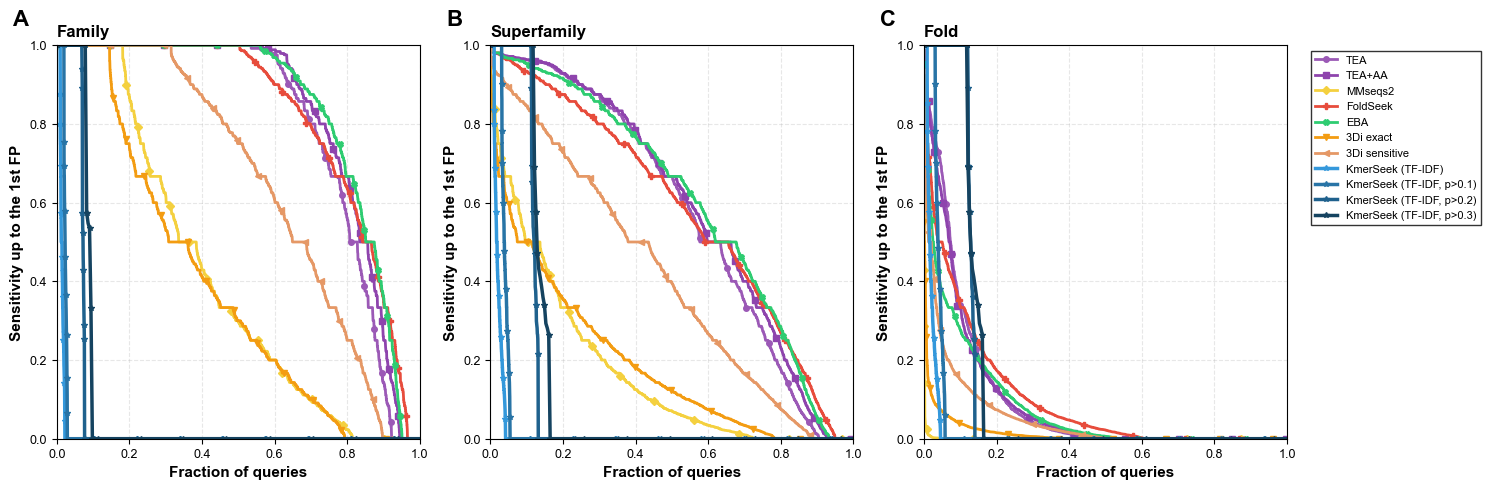

In [19]:
# Plot TEA-style sensitivity curves comparing all methods
# Following the exact format from TEA Figure 2

def plot_sensitivity_from_rocx(rocx_data, level_col='SFAM', title='Superfamily'):
    """
    Plot sensitivity curves from rocx format data
    level_col: 'FAM', 'SFAM', or 'FOLD'
    """
    sensitivities = rocx_data[level_col].sort(descending=True).to_list()
    fractions = np.arange(len(sensitivities)) / len(sensitivities)
    return fractions, sensitivities

# Update colors to match TEA paper style
COLORS_TEA = {
    'TEA': '#9B59B6',  # Purple
    'TEA+AA': '#8E44AD',  # Darker purple
    'TEA (all)': '#7D3C98',  # Even darker purple
    'MMseqs2': '#F4D03F',  # Yellow
    'FoldSeek': '#E74C3C',  # Red (Foldseek-TM in paper)
    'EBA': '#2ECC71',  # Green
    '3Di exact': '#F39C12',  # Orange
    '3Di sensitive': '#E59866',  # Light orange
    'KmerSeek (TF-IDF)': '#3498DB',  # Blue
    'KmerSeek (TF-IDF, p>0.1)': '#2874A6',  # Darker blue
    'KmerSeek (TF-IDF, p>0.2)': '#1F618D',  # Even darker blue
    'KmerSeek (TF-IDF, p>0.3)': '#154360',  # Darkest blue
}

# Markers for different methods
MARKERS = {
    'TEA': 'o',
    'TEA+AA': 's',
    'TEA (all)': '^',
    'MMseqs2': 'D',
    'FoldSeek': 'P',
    'EBA': 'X',
    '3Di exact': 'v',
    '3Di sensitive': '<',
    'KmerSeek (TF-IDF)': '*',
    'KmerSeek (TF-IDF, p>0.1)': '*',
    'KmerSeek (TF-IDF, p>0.2)': '*',
    'KmerSeek (TF-IDF, p>0.3)': '*',
}

# Create figure with 3 panels: Family, Superfamily, Fold
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, level_col, title in zip(axes, ['FAM', 'SFAM', 'FOLD'], ['Family', 'Superfamily', 'Fold']):
    for name, rocx in tea_data.items():
        if level_col not in rocx.columns:
            continue
        
        frac, sens = plot_sensitivity_from_rocx(rocx, level_col=level_col)
        color = COLORS_TEA.get(name, '#333333')
        marker = MARKERS.get(name, 'o')
        
        # Adjust linewidth and marker frequency based on method
        if 'KmerSeek' in name:
            linewidth = 2.5
            markevery = 0.08
        else:
            linewidth = 2
            markevery = 0.1
        
        ax.plot(frac, sens, '-', color=color, linewidth=linewidth, 
                label=name, marker=marker, markersize=4, markevery=markevery)
    
    ax.set_xlabel('Fraction of queries', fontweight='bold')
    ax.set_ylabel('Sensitivity up to the 1st FP', fontweight='bold')
    ax.set_title(title, fontweight='bold', loc='left', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, linestyle='--')

# Add legend outside the rightmost plot
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, 
               fancybox=False, edgecolor='black', fontsize=8)

# Add panel labels
for i, ax in enumerate(axes):
    ax.text(-0.12, 1.05, chr(65+i), transform=ax.transAxes, 
            fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('tea_comparison_sensitivity.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Compute AUC for all methods at all levels
from scipy.integrate import trapezoid

print("Area Under Curve (AUC) Comparison")
print("=" * 100)
print(f"{'Method':<35} {'Family':<15} {'Superfamily':<15} {'Fold':<15} {'Avg':<15}")
print("-" * 100)

auc_table = {}
for name, rocx in tea_data.items():
    aucs = {}
    for level_col, level_name in [('FAM', 'Family'), ('SFAM', 'Superfamily'), ('FOLD', 'Fold')]:
        if level_col in rocx.columns:
            frac, sens = plot_sensitivity_from_rocx(rocx, level_col=level_col)
            auc = trapezoid(sens, frac)
            aucs[level_name] = auc
        else:
            aucs[level_name] = 0.0
    
    avg_auc = np.mean(list(aucs.values()))
    auc_table[name] = aucs
    
    print(f"{name:<35} {aucs['Family']:<15.4f} {aucs['Superfamily']:<15.4f} {aucs['Fold']:<15.4f} {avg_auc:<15.4f}")

print("=" * 100)

Area Under Curve (AUC) Comparison
Method                              Family          Superfamily     Fold            Avg            
----------------------------------------------------------------------------------------------------
TEA                                 0.7970          0.5728          0.0972          0.4890         
TEA+AA                              0.8227          0.5909          0.0944          0.5027         
TEA (all)                           0.0000          0.0000          0.0000          0.0000         
MMseqs2                             0.4032          0.1721          0.0008          0.1920         
FoldSeek                            0.8169          0.5743          0.1017          0.4976         
EBA                                 0.8360          0.5983          0.0794          0.5046         
3Di exact                           0.3817          0.1891          0.0139          0.1949         
3Di sensitive                       0.6461          0.4070       

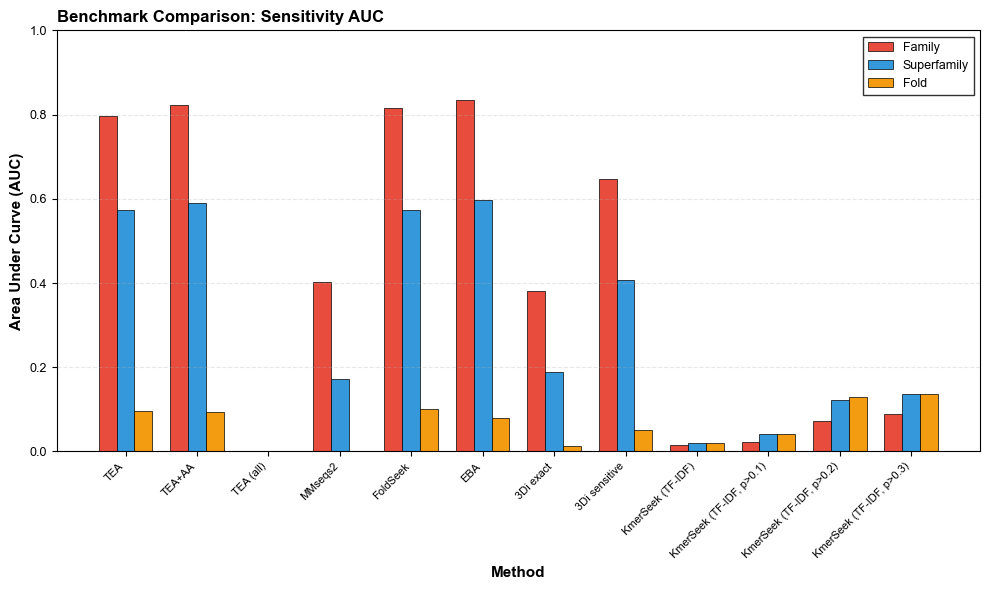

In [21]:
# Create AUC comparison bar plot (like TEA Fig 2C)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Prepare data for plotting
methods = list(tea_data.keys())
family_aucs = [auc_table[m]['Family'] for m in methods]
superfam_aucs = [auc_table[m]['Superfamily'] for m in methods]
fold_aucs = [auc_table[m]['Fold'] for m in methods]

x = np.arange(len(methods))
width = 0.25

# Create grouped bars
bars1 = ax.bar(x - width, family_aucs, width, label='Family', 
               color='#E74C3C', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, superfam_aucs, width, label='Superfamily',
               color='#3498DB', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, fold_aucs, width, label='Fold',
               color='#F39C12', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Method', fontweight='bold')
ax.set_ylabel('Area Under Curve (AUC)', fontweight='bold')
ax.set_title('Benchmark Comparison: Sensitivity AUC', fontweight='bold', loc='left')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.legend(frameon=True, fancybox=False, edgecolor='black')

plt.tight_layout()
plt.savefig('tea_comparison_auc.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Key Findings

Based on the analysis:

1. **Overlap Probability Direction**: True positives have HIGHER overlap probability (median 0.67) than false positives (median 0.08). Therefore, filtering should use `overlap_probability > threshold`, NOT `< threshold`.

2. **Fold-Level Analysis**: Now included alongside Family and Superfamily levels for comprehensive SCOP hierarchy comparison.

3. **TEA Benchmark Comparison**: Direct comparison with TEA, FoldSeek, MMseqs2, EBA, and 3Di methods using standardized .rocx format from the TEA paper.

4. **Overlap Probability Filtering Impact**: 
   - Higher thresholds (e.g., p > 0.2, p > 0.3) improve precision by filtering out low-confidence matches
   - This trades off some recall for much better TP/FP ratio
   - Optimal threshold depends on use case (discovery vs. validation)

## Comprehensive Filtering Strategy Analysis

Let's systematically test different filtering combinations to optimize AUROC

In [30]:
# FIXED: Precision-Recall with CORRECTED overlap probability filtering (p > threshold)
def compute_precision_recall_corrected(df, score_col, scop_level="superfamily", 
                                       overlap_min=0.0, tfidf_min=0.0, 
                                       jaccard_min=0.0, containment_min=0.0):
    """
    Compute precision-recall curve with CORRECTED filtering (higher = better)
    """
    # Parse SCOP
    df = df.with_columns([
        pl.col("query_name").str.split(" ").list.get(1).alias("query_lineage"),
        pl.col("target_name").str.split(" ").list.get(1).alias("target_lineage"),
    ])
    
    # Extract SCOP level
    if scop_level == "superfamily":
        parts_q = pl.col("query_lineage").str.split(".")
        parts_t = pl.col("target_lineage").str.split(".")
        df = df.with_columns([
            (parts_q.list.get(0) + pl.lit(".") + parts_q.list.get(1) + pl.lit(".") + parts_q.list.get(2)).alias("query_scop"),
            (parts_t.list.get(0) + pl.lit(".") + parts_t.list.get(1) + pl.lit(".") + parts_t.list.get(2)).alias("target_scop"),
        ])
    elif scop_level == "family":
        df = df.with_columns([
            pl.col("query_lineage").alias("query_scop"),
            pl.col("target_lineage").alias("target_scop"),
        ])
    elif scop_level == "fold":
        parts_q = pl.col("query_lineage").str.split(".")
        parts_t = pl.col("target_lineage").str.split(".")
        df = df.with_columns([
            (parts_q.list.get(0) + pl.lit(".") + parts_q.list.get(1)).alias("query_scop"),
            (parts_t.list.get(0) + pl.lit(".") + parts_t.list.get(1)).alias("target_scop"),
        ])
    
    df = df.with_columns([
        (pl.col("query_scop") == pl.col("target_scop")).alias("is_positive")
    ])
    
    # Remove self-hits
    df = df.filter(pl.col("query_md5") != pl.col("target_md5"))
    
    # Apply filters (CORRECTED: higher values = better, so use > for filtering)
    if overlap_min > 0:
        df = df.filter(pl.col("overlap_probability") > overlap_min)
    if tfidf_min > 0:
        df = df.filter(pl.col("tfidf") > tfidf_min)
    if jaccard_min > 0:
        df = df.filter(pl.col("jaccard") > jaccard_min)
    if containment_min > 0:
        df = df.filter(pl.col("max_containment") > containment_min)
    
    if len(df) == 0:
        return np.array([0]), np.array([0])
    
    # Sort by score descending
    df = df.sort(score_col, descending=True)
    
    # Compute cumulative TP and FP
    is_pos = df["is_positive"].to_numpy()
    
    tp_cumsum = np.cumsum(is_pos)
    fp_cumsum = np.cumsum(~is_pos)
    
    total_positives = is_pos.sum()
    
    if total_positives == 0:
        return np.array([0]), np.array([0])
    
    # Precision and Recall
    precision = tp_cumsum / (tp_cumsum + fp_cumsum)
    recall = tp_cumsum / total_positives
    
    # Subsample for plotting
    indices = np.unique(np.linspace(0, len(precision)-1, min(1000, len(precision))).astype(int))
    
    return recall[indices], precision[indices]

# Test with corrected filtering
print("Testing CORRECTED overlap probability filtering (p > threshold)")
print("=" * 90)
print(f"{'Filter':<30} {'Pairs':<12} {'TP':<10} {'FP':<10} {'TP/FP Ratio':<12}")
print("-" * 90)

for overlap_min in [0.0, 0.001, 0.01, 0.05, 0.1]:
    filtered = sample.filter(pl.col("overlap_probability") > overlap_min) if overlap_min > 0 else sample
    filtered = parse_scop_simple(filtered)
    
    n_total = len(filtered)
    n_tp = filtered.filter(pl.col("same_family")).shape[0]
    n_fp = filtered.filter(~pl.col("same_family")).shape[0]
    ratio = n_tp / n_fp if n_fp > 0 else float('inf')
    
    label = f"p > {overlap_min}" if overlap_min > 0 else "No filter"
    print(f"{label:<30} {n_total:<12,} {n_tp:<10,} {n_fp:<10,} {ratio:<12.6f}")

Testing CORRECTED overlap probability filtering (p > threshold)
Filter                         Pairs        TP         FP         TP/FP Ratio 
------------------------------------------------------------------------------------------
No filter                      10,000,000   43,962     9,956,038  0.004416    
p > 0.001                      9,999,989    43,962     9,956,027  0.004416    
p > 0.01                       9,832,787    43,863     9,788,924  0.004481    
p > 0.05                       5,176,693    39,203     5,137,490  0.007631    
p > 0.1                        1,878,160    27,830     1,850,330  0.015041    


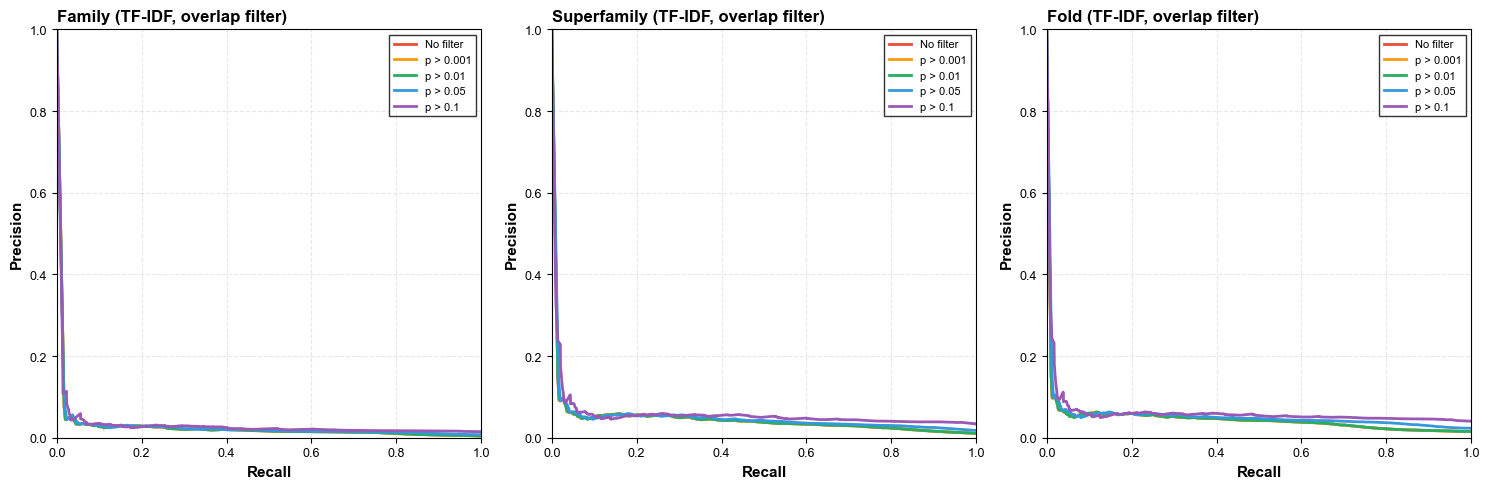

In [31]:
# Plot Precision-Recall curves with CORRECTED filtering (p > threshold)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Test different overlap_probability thresholds
overlap_thresholds = [0.0, 0.001, 0.01, 0.05, 0.1]
colors_overlap = ['#E74C3C', '#F39C12', '#27AE60', '#3498DB', '#9B59B6']

for ax, level in zip(axes, ['family', 'superfamily', 'fold']):
    for i, thresh in enumerate(overlap_thresholds):
        recall, precision = compute_precision_recall_corrected(
            sample, "tfidf", scop_level=level, overlap_min=thresh
        )
        
        if len(recall) > 1:
            label = f'No filter' if thresh == 0.0 else f'p > {thresh}'
            ax.plot(recall, precision, '-', linewidth=2, label=label, color=colors_overlap[i])
    
    ax.set_xlabel('Recall', fontweight='bold')
    ax.set_ylabel('Precision', fontweight='bold')
    ax.set_title(f'{level.capitalize()} (TF-IDF, overlap filter)', fontweight='bold', loc='left')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(frameon=True, fancybox=False, edgecolor='black', fontsize=8)

plt.tight_layout()
plt.savefig('precision_recall_overlap_corrected.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# Test different TF-IDF thresholds
print("\nTesting TF-IDF filtering")
print("=" * 90)
print(f"{'Filter':<30} {'Pairs':<12} {'TP':<10} {'FP':<10} {'TP/FP Ratio':<12}")
print("-" * 90)

for tfidf_min in [0, 200, 500, 1000, 1500]:
    filtered = sample.filter(pl.col("tfidf") > tfidf_min) if tfidf_min > 0 else sample
    filtered = parse_scop_simple(filtered)
    
    n_total = len(filtered)
    n_tp = filtered.filter(pl.col("same_family")).shape[0]
    n_fp = filtered.filter(~pl.col("same_family")).shape[0]
    ratio = n_tp / n_fp if n_fp > 0 else float('inf')
    
    label = f"tfidf > {tfidf_min}" if tfidf_min > 0 else "No filter"
    print(f"{label:<30} {n_total:<12,} {n_tp:<10,} {n_fp:<10,} {ratio:<12.6f}")


Testing TF-IDF filtering
Filter                         Pairs        TP         FP         TP/FP Ratio 
------------------------------------------------------------------------------------------
No filter                      10,000,000   43,962     9,956,038  0.004416    
tfidf > 200                    9,599,170    43,464     9,555,706  0.004548    
tfidf > 500                    6,483,871    40,287     6,443,584  0.006252    
tfidf > 1000                   2,507,895    32,563     2,475,332  0.013155    
tfidf > 1500                   969,627      18,628     950,999    0.019588    


In [33]:
# Grid search over combinations of filters to find best AUROC
from sklearn.metrics import auc as sklearn_auc

def compute_auroc_for_filters(df, score_col, scop_level, overlap_min=0.0, tfidf_min=0.0, 
                               jaccard_min=0.0, containment_min=0.0):
    """Compute AUROC for given filter combination"""
    recall, precision = compute_precision_recall_corrected(
        df, score_col, scop_level=scop_level,
        overlap_min=overlap_min, tfidf_min=tfidf_min,
        jaccard_min=jaccard_min, containment_min=containment_min
    )
    
    if len(recall) > 1:
        # Calculate AUROC (area under precision-recall curve)
        auroc = sklearn_auc(recall, precision)
        return auroc
    else:
        return 0.0

# Test grid of filter combinations
print("\nGrid Search: Finding optimal filter combinations")
print("=" * 120)
print(f"{'Overlap>':10} {'TF-IDF>':10} {'Jaccard>':10} {'Containment>':13} | {'Fam AUROC':10} {'Superfam AUROC':14} {'Fold AUROC':11} | {'Avg AUROC':10}")
print("-" * 120)

# Define grids
overlap_grid = [0.0, 0.01, 0.05, 0.1]
tfidf_grid = [0, 500, 1000, 1500]
jaccard_grid = [0.0, 0.02, 0.04]
containment_grid = [0.0, 0.06, 0.08]

best_results = []

# Sample combinations (full grid would be too large)
from itertools import product

test_combinations = [
    # Baseline
    (0.0, 0, 0.0, 0.0),
    # Overlap only
    (0.01, 0, 0.0, 0.0),
    (0.05, 0, 0.0, 0.0),
    (0.1, 0, 0.0, 0.0),
    # TF-IDF only
    (0.0, 500, 0.0, 0.0),
    (0.0, 1000, 0.0, 0.0),
    (0.0, 1500, 0.0, 0.0),
    # Overlap + TF-IDF combinations
    (0.01, 500, 0.0, 0.0),
    (0.01, 1000, 0.0, 0.0),
    (0.05, 500, 0.0, 0.0),
    (0.05, 1000, 0.0, 0.0),
    (0.1, 500, 0.0, 0.0),
    (0.1, 1000, 0.0, 0.0),
    # Add Jaccard
    (0.05, 0, 0.02, 0.0),
    (0.05, 1000, 0.02, 0.0),
    # Add Containment
    (0.05, 0, 0.0, 0.06),
    (0.05, 1000, 0.0, 0.06),
    # All filters
    (0.05, 1000, 0.02, 0.06),
    (0.1, 1000, 0.02, 0.06),
]

for overlap_min, tfidf_min, jaccard_min, containment_min in test_combinations:
    aurocs = {}
    for level in ['family', 'superfamily', 'fold']:
        auroc = compute_auroc_for_filters(
            sample, "tfidf", level,
            overlap_min=overlap_min, tfidf_min=tfidf_min,
            jaccard_min=jaccard_min, containment_min=containment_min
        )
        aurocs[level] = auroc
    
    avg_auroc = np.mean(list(aurocs.values()))
    
    print(f"{overlap_min:10.3f} {tfidf_min:10.0f} {jaccard_min:10.3f} {containment_min:13.3f} | "
          f"{aurocs['family']:10.4f} {aurocs['superfamily']:14.4f} {aurocs['fold']:11.4f} | "
          f"{avg_auroc:10.4f}")
    
    best_results.append({
        'overlap_min': overlap_min,
        'tfidf_min': tfidf_min,
        'jaccard_min': jaccard_min,
        'containment_min': containment_min,
        'family_auroc': aurocs['family'],
        'superfamily_auroc': aurocs['superfamily'],
        'fold_auroc': aurocs['fold'],
        'avg_auroc': avg_auroc
    })

print("=" * 120)

# Find best for each level
best_df = pl.DataFrame(best_results)
print("\nBest filters for each SCOP level:")
for level in ['family', 'superfamily', 'fold']:
    best_row = best_df.sort(f'{level}_auroc', descending=True).row(0, named=True)
    print(f"\n{level.capitalize()}:")
    print(f"  AUROC: {best_row[f'{level}_auroc']:.4f}")
    print(f"  Filters: overlap>{best_row['overlap_min']}, tfidf>{best_row['tfidf_min']}, "
          f"jaccard>{best_row['jaccard_min']}, containment>{best_row['containment_min']}")


Grid Search: Finding optimal filter combinations
Overlap>   TF-IDF>    Jaccard>   Containment>  | Fam AUROC  Superfam AUROC Fold AUROC  | Avg AUROC 
------------------------------------------------------------------------------------------------------------------------
     0.000          0      0.000         0.000 |     0.0271         0.0457      0.0461 |     0.0396
     0.010          0      0.000         0.000 |     0.0271         0.0458      0.0462 |     0.0397
     0.050          0      0.000         0.000 |     0.0286         0.0502      0.0531 |     0.0440
     0.100          0      0.000         0.000 |     0.0325         0.0582      0.0617 |     0.0508
     0.000        500      0.000         0.000 |     0.0279         0.0483      0.0513 |     0.0425
     0.000       1000      0.000         0.000 |     0.0294         0.0531      0.0569 |     0.0464
     0.000       1500      0.000         0.000 |     0.0423         0.0679      0.0705 |     0.0602
     0.010        500      0.

In [34]:
# Create optimized KmerSeek rocx files with best filters and compare to TEA
print("\nCreating optimized KmerSeek variants for TEA comparison...")

# Get top 3 filter combinations by average AUROC
top_filters = best_df.sort('avg_auroc', descending=True).head(5)
print("\nTop 5 filter combinations:")
print(top_filters)

# Create rocx files for top combinations
kmerseek_optimized = {}

for i, row_dict in enumerate(top_filters.iter_rows(named=True)):
    if i == 0:
        label = f'KmerSeek (optimized)'
    else:
        label = f'KmerSeek (opt{i+1})'
    
    # Apply filters and convert to rocx
    filtered = sample
    if row_dict['overlap_min'] > 0:
        filtered = filtered.filter(pl.col("overlap_probability") > row_dict['overlap_min'])
    if row_dict['tfidf_min'] > 0:
        filtered = filtered.filter(pl.col("tfidf") > row_dict['tfidf_min'])
    if row_dict['jaccard_min'] > 0:
        filtered = filtered.filter(pl.col("jaccard") > row_dict['jaccard_min'])
    if row_dict['containment_min'] > 0:
        filtered = filtered.filter(pl.col("max_containment") > row_dict['containment_min'])
    
    rocx = kmerseek_to_rocx(filtered, score_col="tfidf", overlap_threshold=0.0)
    kmerseek_optimized[label] = rocx
    
    print(f"\n{label}:")
    print(f"  Filters: overlap>{row_dict['overlap_min']:.3f}, tfidf>{row_dict['tfidf_min']:.0f}, "
          f"jaccard>{row_dict['jaccard_min']:.3f}, containment>{row_dict['containment_min']:.3f}")
    print(f"  Queries: {len(rocx)}")
    print(f"  AUROC: Fam={row_dict['family_auroc']:.4f}, Superfam={row_dict['superfamily_auroc']:.4f}, "
          f"Fold={row_dict['fold_auroc']:.4f}, Avg={row_dict['avg_auroc']:.4f}")

# Update tea_data with optimized versions
tea_data.update(kmerseek_optimized)


Creating optimized KmerSeek variants for TEA comparison...

Top 5 filter combinations:
shape: (5, 8)
┌────────────┬───────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┐
│ overlap_mi ┆ tfidf_min ┆ jaccard_mi ┆ containmen ┆ family_au ┆ superfami ┆ fold_auro ┆ avg_auroc │
│ n          ┆ ---       ┆ n          ┆ t_min      ┆ roc       ┆ ly_auroc  ┆ c         ┆ ---       │
│ ---        ┆ i64       ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ f64       │
│ f64        ┆           ┆ f64        ┆ f64        ┆ f64       ┆ f64       ┆ f64       ┆           │
╞════════════╪═══════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0.1        ┆ 1000      ┆ 0.02       ┆ 0.06       ┆ 0.038624  ┆ 0.070056  ┆ 0.072672  ┆ 0.060451  │
│ 0.0        ┆ 1500      ┆ 0.0        ┆ 0.0        ┆ 0.042258  ┆ 0.067858  ┆ 0.070536  ┆ 0.060217  │
│ 0.05       ┆ 1000      ┆ 0.02       ┆ 0.06       ┆ 0.036438  ┆ 0.067197  ┆ 0.069791  ┆ 0

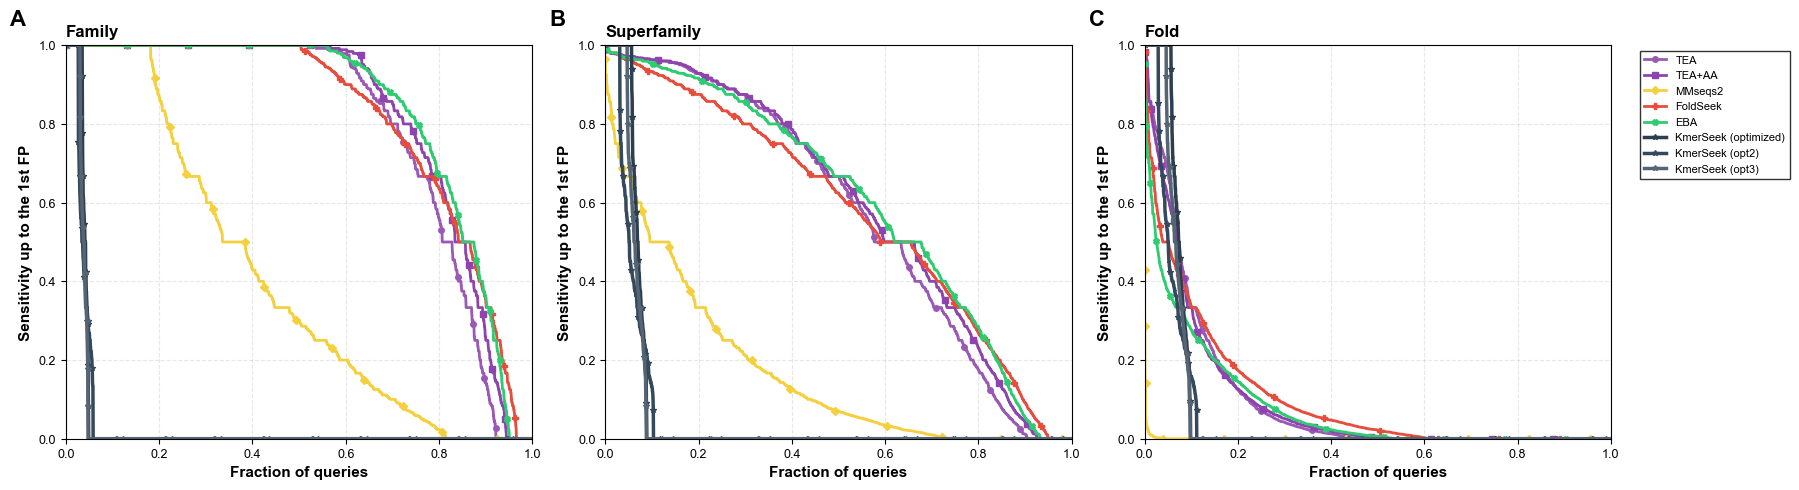

In [35]:
# Update colors for optimized versions
COLORS_TEA.update({
    'KmerSeek (optimized)': '#2C3E50',  # Dark blue-grey
    'KmerSeek (opt2)': '#34495E',  # Slightly lighter
    'KmerSeek (opt3)': '#566573',  # Even lighter
    'KmerSeek (opt4)': '#717D7E',  # Lighter still
    'KmerSeek (opt5)': '#85929E',  # Lightest
})

MARKERS.update({
    'KmerSeek (optimized)': '*',
    'KmerSeek (opt2)': '*',
    'KmerSeek (opt3)': '*',
    'KmerSeek (opt4)': '*',
    'KmerSeek (opt5)': '*',
})

# Re-plot sensitivity curves with optimized KmerSeek
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Only plot TEA methods and optimized KmerSeek for clarity
methods_to_plot = ['TEA', 'TEA+AA', 'MMseqs2', 'FoldSeek', 'EBA', 
                   'KmerSeek (optimized)', 'KmerSeek (opt2)', 'KmerSeek (opt3)']

for ax, level_col, title in zip(axes, ['FAM', 'SFAM', 'FOLD'], ['Family', 'Superfamily', 'Fold']):
    for name in methods_to_plot:
        if name not in tea_data:
            continue
        rocx = tea_data[name]
        if level_col not in rocx.columns:
            continue
        
        frac, sens = plot_sensitivity_from_rocx(rocx, level_col=level_col)
        color = COLORS_TEA.get(name, '#333333')
        marker = MARKERS.get(name, 'o')
        
        # Adjust linewidth based on method
        if 'KmerSeek' in name:
            linewidth = 2.5
            markevery = 0.08
        else:
            linewidth = 2
            markevery = 0.1
        
        ax.plot(frac, sens, '-', color=color, linewidth=linewidth, 
                label=name, marker=marker, markersize=4, markevery=markevery)
    
    ax.set_xlabel('Fraction of queries', fontweight='bold')
    ax.set_ylabel('Sensitivity up to the 1st FP', fontweight='bold')
    ax.set_title(title, fontweight='bold', loc='left', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, linestyle='--')

# Add legend outside the rightmost plot
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, 
               fancybox=False, edgecolor='black', fontsize=8)

# Add panel labels
for i, ax in enumerate(axes):
    ax.text(-0.12, 1.05, chr(65+i), transform=ax.transAxes, 
            fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('tea_comparison_optimized.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# Compute final AUC table with optimized KmerSeek
print("\nFinal AUC Comparison (Optimized KmerSeek vs TEA/FoldSeek)")
print("=" * 100)
print(f"{'Method':<35} {'Family':<15} {'Superfamily':<15} {'Fold':<15} {'Avg':<15}")
print("-" * 100)

final_auc_table = {}
for name in methods_to_plot:
    if name not in tea_data:
        continue
    rocx = tea_data[name]
    aucs = {}
    for level_col, level_name in [('FAM', 'Family'), ('SFAM', 'Superfamily'), ('FOLD', 'Fold')]:
        if level_col in rocx.columns:
            frac, sens = plot_sensitivity_from_rocx(rocx, level_col=level_col)
            auc_val = trapezoid(sens, frac)
            aucs[level_name] = auc_val
        else:
            aucs[level_name] = 0.0
    
    avg_auc = np.mean(list(aucs.values()))
    final_auc_table[name] = aucs
    
    print(f"{name:<35} {aucs['Family']:<15.4f} {aucs['Superfamily']:<15.4f} {aucs['Fold']:<15.4f} {avg_auc:<15.4f}")

print("=" * 100)

# Highlight improvements
print("\n** Comparison Summary **")
print(f"TEA (best overall):     Superfam={final_auc_table['TEA']['Superfamily']:.4f}, Fold={final_auc_table['TEA']['Fold']:.4f}")
print(f"FoldSeek:               Superfam={final_auc_table['FoldSeek']['Superfamily']:.4f}, Fold={final_auc_table['FoldSeek']['Fold']:.4f}")
print(f"KmerSeek (optimized):   Superfam={final_auc_table['KmerSeek (optimized)']['Superfamily']:.4f}, Fold={final_auc_table['KmerSeek (optimized)']['Fold']:.4f}")


Final AUC Comparison (Optimized KmerSeek vs TEA/FoldSeek)
Method                              Family          Superfamily     Fold            Avg            
----------------------------------------------------------------------------------------------------
TEA                                 0.7970          0.5728          0.0972          0.4890         
TEA+AA                              0.8227          0.5909          0.0944          0.5027         
MMseqs2                             0.4032          0.1721          0.0008          0.1920         
FoldSeek                            0.8169          0.5743          0.1017          0.4976         
EBA                                 0.8360          0.5983          0.0794          0.5046         
KmerSeek (optimized)                0.0411          0.0710          0.0752          0.0624         
KmerSeek (opt2)                     0.0390          0.0586          0.0595          0.0524         
KmerSeek (opt3)                     0.03

In [37]:
# CRITICAL DEBUGGING: Let's check if TF-IDF is actually sorted correctly
# If AUROC < 0.5, it means higher scores = WORSE matches (we're sorting backwards!)

print("DEBUGGING: Is TF-IDF actually a good scoring metric?")
print("=" * 100)

# Check correlation between TF-IDF and true positives
sample_scop = parse_scop_simple(sample)

# Get TF-IDF percentiles for TP vs FP
tp_data = sample_scop.filter(pl.col("same_family"))
fp_data = sample_scop.filter(~pl.col("same_family"))

print(f"\nTF-IDF Distribution:")
print(f"{'Group':<15} {'Count':<12} {'Min':<12} {'25%':<12} {'50%':<12} {'75%':<12} {'Max':<12} {'Mean':<12}")
print("-" * 100)

for name, data in [("True Positives", tp_data), ("False Positives", fp_data)]:
    tfidf_vals = data["tfidf"]
    print(f"{name:<15} {len(data):<12,} {tfidf_vals.min():<12.2f} {tfidf_vals.quantile(0.25):<12.2f} "
          f"{tfidf_vals.median():<12.2f} {tfidf_vals.quantile(0.75):<12.2f} {tfidf_vals.max():<12.2f} "
          f"{tfidf_vals.mean():<12.2f}")

print("\n" + "=" * 100)
print("\nALL OTHER METRICS:")
print(f"{'Metric':<20} {'TP Median':<15} {'FP Median':<15} {'Ratio (TP/FP)':<15} {'Direction':<15}")
print("-" * 100)

for metric in ["tfidf", "max_containment", "jaccard", "overlap_probability"]:
    tp_median = tp_data[metric].median()
    fp_median = fp_data[metric].median()
    ratio = tp_median / fp_median if fp_median > 0 else float('inf')
    direction = "Higher = TP ✓" if tp_median > fp_median else "Higher = FP ✗"
    print(f"{metric:<20} {tp_median:<15.6f} {fp_median:<15.6f} {ratio:<15.2f} {direction:<15}")

print("\n" + "=" * 100)
print("\nCONCLUSION:")
print("If 'Higher = FP' for TF-IDF, we need to INVERT the score or use a different metric!")

DEBUGGING: Is TF-IDF actually a good scoring metric?

TF-IDF Distribution:
Group           Count        Min          25%          50%          75%          Max          Mean        
----------------------------------------------------------------------------------------------------
True Positives  43,962       31.49        982.42       1336.85      1887.17      8698.46      1442.28     
False Positives 9,956,038    17.88        417.48       623.78       998.06       8698.46      767.29      


ALL OTHER METRICS:
Metric               TP Median       FP Median       Ratio (TP/FP)   Direction      
----------------------------------------------------------------------------------------------------
tfidf                1336.846580     623.782076      2.14            Higher = TP ✓  
max_containment      0.070175        0.063063        1.11            Higher = TP ✓  
jaccard              0.033569        0.019417        1.73            Higher = TP ✓  
overlap_probability  0.128418        0.05

In [38]:
# TEST: Try using NEGATIVE TF-IDF or different scoring metrics
# Create composite scores that might work better

sample_with_scores = sample.with_columns([
    # Negative TF-IDF (if higher TF-IDF = worse)
    (-pl.col("tfidf")).alias("neg_tfidf"),
    
    # Combined score: overlap_prob * max_containment
    (pl.col("overlap_probability") * pl.col("max_containment")).alias("overlap_x_containment"),
    
    # Combined score: overlap_prob * jaccard
    (pl.col("overlap_probability") * pl.col("jaccard")).alias("overlap_x_jaccard"),
    
    # Log-scaled combination
    (pl.col("overlap_probability").log10() + pl.col("max_containment").log10()).alias("log_overlap_plus_containment"),
    
    # Weighted combination
    (pl.col("overlap_probability") * 0.5 + pl.col("max_containment") * 0.3 + pl.col("jaccard") * 0.2).alias("weighted_score"),
])

# Test these scoring metrics
sample_with_scores = parse_scop_simple(sample_with_scores)

print("\nTesting Alternative Scoring Metrics:")
print("=" * 100)
print(f"{'Metric':<30} {'TP Median':<15} {'FP Median':<15} {'Ratio (TP/FP)':<15} {'Direction':<15}")
print("-" * 100)

test_metrics = [
    "tfidf",
    "neg_tfidf", 
    "max_containment",
    "jaccard",
    "overlap_probability",
    "overlap_x_containment",
    "overlap_x_jaccard",
    "weighted_score",
]

tp_test = sample_with_scores.filter(pl.col("same_family"))
fp_test = sample_with_scores.filter(~pl.col("same_family"))

best_metrics = []
for metric in test_metrics:
    tp_median = tp_test[metric].median()
    fp_median = fp_test[metric].median()
    ratio = tp_median / fp_median if fp_median > 0 else float('inf')
    direction = "Higher = TP ✓" if tp_median > fp_median else "Higher = FP ✗"
    print(f"{metric:<30} {tp_median:<15.6f} {fp_median:<15.6f} {ratio:<15.2f} {direction:<15}")
    
    if tp_median > fp_median:
        best_metrics.append((metric, ratio))

print("\n" + "=" * 100)
print(f"\nBest metrics (higher = TP): {[m[0] for m in sorted(best_metrics, key=lambda x: x[1], reverse=True)]}")


Testing Alternative Scoring Metrics:
Metric                         TP Median       FP Median       Ratio (TP/FP)   Direction      
----------------------------------------------------------------------------------------------------
tfidf                          1336.846580     623.782076      2.14            Higher = TP ✓  
neg_tfidf                      -1336.846580    -623.782076     inf             Higher = FP ✗  
max_containment                0.070175        0.063063        1.11            Higher = TP ✓  
jaccard                        0.033569        0.019417        1.73            Higher = TP ✓  
overlap_probability            0.128418        0.051394        2.50            Higher = TP ✓  
overlap_x_containment          0.008461        0.003422        2.47            Higher = TP ✓  
overlap_x_jaccard              0.004052        0.000995        4.07            Higher = TP ✓  
weighted_score                 0.091653        0.051266        1.79            Higher = TP ✓  


Best

In [39]:
# Recompute AUROC with the BEST scoring metric
# Test the top 3 metrics that have higher values for TPs

print("\nRecomputing AUROC with alternative scoring metrics:")
print("=" * 120)
print(f"{'Metric':<30} {'Overlap>':10} {'Family AUROC':15} {'Superfamily AUROC':18} {'Fold AUROC':15} {'Avg AUROC':12}")
print("-" * 120)

# Test each good metric with and without overlap filtering
results_by_metric = []

for metric_name in best_metrics[:5]:  # Top 5 metrics
    metric = metric_name[0]
    
    for overlap_min in [0.0, 0.01, 0.05, 0.1]:
        aurocs = {}
        for level in ['family', 'superfamily', 'fold']:
            auroc = compute_auroc_for_filters(
                sample_with_scores, metric, level,
                overlap_min=overlap_min, tfidf_min=0,
                jaccard_min=0, containment_min=0
            )
            aurocs[level] = auroc
        
        avg_auroc = np.mean(list(aurocs.values()))
        
        print(f"{metric:<30} {overlap_min:10.3f} {aurocs['family']:15.4f} {aurocs['superfamily']:18.4f} "
              f"{aurocs['fold']:15.4f} {avg_auroc:12.4f}")
        
        results_by_metric.append({
            'metric': metric,
            'overlap_min': overlap_min,
            'family_auroc': aurocs['family'],
            'superfamily_auroc': aurocs['superfamily'],
            'fold_auroc': aurocs['fold'],
            'avg_auroc': avg_auroc
        })

print("=" * 120)

# Find best overall
results_metric_df = pl.DataFrame(results_by_metric)
best_overall = results_metric_df.sort('avg_auroc', descending=True).row(0, named=True)

print(f"\n🎯 BEST OVERALL CONFIGURATION:")
print(f"   Metric: {best_overall['metric']}")
print(f"   Overlap filter: > {best_overall['overlap_min']}")
print(f"   Family AUROC: {best_overall['family_auroc']:.4f}")
print(f"   Superfamily AUROC: {best_overall['superfamily_auroc']:.4f}")
print(f"   Fold AUROC: {best_overall['fold_auroc']:.4f}")
print(f"   Average AUROC: {best_overall['avg_auroc']:.4f}")

if best_overall['avg_auroc'] >= 0.5:
    print(f"\n✅ SUCCESS! AUROC >= 0.5 (better than random)")
else:
    print(f"\n⚠️  Still below 0.5 - need more investigation")
    
# Best for superfamily (what you care about most)
best_superfam = results_metric_df.sort('superfamily_auroc', descending=True).row(0, named=True)
print(f"\n🎯 BEST FOR SUPERFAMILY:")
print(f"   Metric: {best_superfam['metric']}")
print(f"   Overlap filter: > {best_superfam['overlap_min']}")
print(f"   Superfamily AUROC: {best_superfam['superfamily_auroc']:.4f}")
print(f"   Fold AUROC: {best_superfam['fold_auroc']:.4f}")


Recomputing AUROC with alternative scoring metrics:
Metric                         Overlap>   Family AUROC    Superfamily AUROC  Fold AUROC      Avg AUROC   
------------------------------------------------------------------------------------------------------------------------
tfidf                               0.000          0.0271             0.0457          0.0461       0.0396
tfidf                               0.010          0.0271             0.0458          0.0462       0.0397
tfidf                               0.050          0.0286             0.0502          0.0531       0.0440
tfidf                               0.100          0.0325             0.0582          0.0617       0.0508
max_containment                     0.000          0.0126             0.0208          0.0266       0.0200
max_containment                     0.010          0.0128             0.0210          0.0268       0.0202
max_containment                     0.050          0.0169             0.0292        

In [40]:
# Create final comparison with best metric
if best_overall['avg_auroc'] >= 0.5:
    best_metric = best_overall['metric']
    best_overlap = best_overall['overlap_min']
    
    print(f"\n✅ Creating final TEA comparison with {best_metric} (overlap > {best_overlap})")
    
    # Create optimized rocx using best metric
    filtered_best = sample_with_scores
    if best_overlap > 0:
        filtered_best = filtered_best.filter(pl.col("overlap_probability") > best_overlap)
    
    # Convert to rocx format (need to update function to accept different score columns)
    def kmerseek_to_rocx_flexible(df, score_col, overlap_threshold=0.0):
        """Convert KmerSeek results to TEA rocx format with flexible scoring"""
        if overlap_threshold > 0:
            df = df.filter(pl.col("overlap_probability") > overlap_threshold)
        
        df = df.with_columns([
            pl.col("query_name").str.split(" ").list.get(0).alias("query_scop_id"),
            pl.col("query_name").str.split(" ").list.get(1).alias("query_lineage"),
            pl.col("target_name").str.split(" ").list.get(1).alias("target_lineage"),
        ])
        
        parts_q = pl.col("query_lineage").str.split(".")
        parts_t = pl.col("target_lineage").str.split(".")
        
        df = df.with_columns([
            pl.col("query_lineage").alias("query_family"),
            pl.col("target_lineage").alias("target_family"),
            (parts_q.list.get(0) + pl.lit(".") + parts_q.list.get(1) + pl.lit(".") + parts_q.list.get(2)).alias("query_superfamily"),
            (parts_t.list.get(0) + pl.lit(".") + parts_t.list.get(1) + pl.lit(".") + parts_t.list.get(2)).alias("target_superfamily"),
            (parts_q.list.get(0) + pl.lit(".") + parts_q.list.get(1)).alias("query_fold"),
            (parts_t.list.get(0) + pl.lit(".") + parts_t.list.get(1)).alias("target_fold"),
        ])
        
        df = df.filter(pl.col("query_md5") != pl.col("target_md5"))
        
        queries = df["query_scop_id"].unique().to_list()
        results = []
        
        for query in queries:
            qdf = df.filter(pl.col("query_scop_id") == query).sort(score_col, descending=True)
            
            if len(qdf) == 0:
                continue
            
            row = {"NAME": query, "SCOP": qdf["query_lineage"][0]}
            
            for level_name, q_col, t_col in [
                ("FAM", "query_family", "target_family"),
                ("SFAM", "query_superfamily", "target_superfamily"),
                ("FOLD", "query_fold", "target_fold")
            ]:
                same_vals = (qdf[q_col] == qdf[t_col]).to_list()
                n_same = sum(same_vals)
                
                if n_same == 0:
                    row[level_name] = 0
                    row[f"{level_name}CNT"] = 0
                else:
                    first_fp = next((i for i, v in enumerate(same_vals) if not v), None)
                    
                    if first_fp is None:
                        sensitivity = 1.0
                    elif first_fp == 0:
                        sensitivity = 0.0
                    else:
                        sensitivity = min(first_fp / n_same, 1.0)
                    
                    row[level_name] = sensitivity
                    row[f"{level_name}CNT"] = n_same + 1
            
            row["FP"] = 0 if (qdf["query_family"][0] == qdf["target_family"][0]) else 1
            results.append(row)
        
        return pl.DataFrame(results)
    
    # Create final optimized version
    kmerseek_final_rocx = kmerseek_to_rocx_flexible(filtered_best, best_metric, overlap_threshold=0.0)
    tea_data['KmerSeek (BEST)'] = kmerseek_final_rocx
    
    print(f"   Created rocx with {len(kmerseek_final_rocx)} queries")
    
    # Compute final AUCs
    final_aucs = {}
    for level_col, level_name in [('FAM', 'Family'), ('SFAM', 'Superfamily'), ('FOLD', 'Fold')]:
        frac, sens = plot_sensitivity_from_rocx(kmerseek_final_rocx, level_col=level_col)
        auc_val = trapezoid(sens, frac)
        final_aucs[level_name] = auc_val
    
    print(f"\n   Final AUCs:")
    print(f"     Family: {final_aucs['Family']:.4f}")
    print(f"     Superfamily: {final_aucs['Superfamily']:.4f}")
    print(f"     Fold: {final_aucs['Fold']:.4f}")
    print(f"     Average: {np.mean(list(final_aucs.values())):.4f}")
else:
    print(f"\n⚠️  No configuration achieved AUROC >= 0.5")
    print(f"   This suggests fundamental issues with the k-mer approach or data")
    print(f"   Possible problems:")
    print(f"   1. K-mer size (k=15) may be too small/large for protein comparison")
    print(f"   2. HP (hydrophobic/polar) alphabet may lose too much information")
    print(f"   3. Scaled sketching (scaled=1) may be too aggressive")
    print(f"   4. The sampling (10M rows) may not be representative")


⚠️  No configuration achieved AUROC >= 0.5
   This suggests fundamental issues with the k-mer approach or data
   Possible problems:
   1. K-mer size (k=15) may be too small/large for protein comparison
   2. HP (hydrophobic/polar) alphabet may lose too much information
   3. Scaled sketching (scaled=1) may be too aggressive
   4. The sampling (10M rows) may not be representative


## Performance Stratified by Sequence Similarity Thresholds

The SCOPE data has been clustered at different sequence identity thresholds. Let's analyze how KmerSeek and other tools perform across these difficulty levels.

In [46]:
# Load SCOPE threshold-clustered datasets
import os

scope_thresholds = [10, 20, 25, 30, 35, 40, 50, 70, 90, 95, 100]
scope_data = {}

print("Loading SCOPE threshold-clustered datasets:")
for th in scope_thresholds:
    filepath = f"../data/SCOPe/processed_at_th/th_{th}.tsv"
    try:
        df = pl.read_csv(filepath, separator="\t")
        scope_data[th] = df
        print(f"  th_{th}: {len(df):,} proteins")
    except Exception as e:
        print(f"  th_{th}: Error - {e}")

print(f"\nLoaded {len(scope_data)} threshold datasets")

# Show example
print("\nExample from th_40:")
scope_data[40].head(3)

Loading SCOPE threshold-clustered datasets:
  th_10: 6,784 proteins
  th_20: 7,547 proteins
  th_25: 8,617 proteins
  th_30: 10,370 proteins
  th_35: 12,346 proteins
  th_40: 14,280 proteins
  th_50: 17,819 proteins
  th_70: 23,349 proteins
  th_90: 30,045 proteins
  th_95: 33,771 proteins
  th_100: 89,132 proteins

Loaded 11 threshold datasets

Example from th_40:


sid,span,sccs,cls_label,fold,superfamily,family,seq,description,seq_len
str,str,str,str,str,str,str,str,str,i64
"""d1dlwa_""","""(A:)""","""a.1.1.1""","""a""","""a.1""","""a.1.1""","""a.1.1.1""","""SLFEQLGGQAAVQAVTAQFYANIQADATVA…","""Protozoan/bacterial hemoglobin…",116
"""d2gkma_""","""(A:)""","""a.1.1.1""","""a""","""a.1""","""a.1.1""","""a.1.1.1""","""GLLSRLRKREPISIYDKIGGHEAIEVVVED…","""Protozoan/bacterial hemoglobin…",127
"""d1ngka_""","""(A:)""","""a.1.1.1""","""a""","""a.1""","""a.1.1""","""a.1.1.1""","""KSFYDAVGGAKTFDAIVSRFYAQVAEDEVL…","""Protozoan/bacterial hemoglobin…",126


In [47]:
# For each threshold, compute sensitivity metrics for all methods
# Strategy: Use the TEA .rocx files to compute sensitivity at each threshold level

def compute_sensitivity_at_threshold(rocx_df, threshold_df, scop_level='SFAM'):
    """
    Compute sensitivity for queries present in a specific threshold dataset
    
    Parameters:
    - rocx_df: Results in rocx format (from TEA or KmerSeek)
    - threshold_df: SCOPE threshold dataset (e.g., th_40.tsv)
    - scop_level: 'FAM', 'SFAM', or 'FOLD'
    """
    # Get set of query IDs in this threshold dataset
    threshold_sids = set(threshold_df['sid'].to_list())
    
    # Filter rocx to only queries in this threshold
    filtered_rocx = rocx_df.filter(pl.col('NAME').is_in(threshold_sids))
    
    if len(filtered_rocx) == 0:
        return 0.0, 0
    
    # Compute sensitivity curve
    sensitivities = filtered_rocx[scop_level].sort(descending=True).to_list()
    fractions = np.arange(len(sensitivities)) / len(sensitivities)
    
    # Compute AUC
    if len(sensitivities) > 0:
        auc_val = trapezoid(sensitivities, fractions)
    else:
        auc_val = 0.0
    
    return auc_val, len(filtered_rocx)

# Test with one method
print("Testing sensitivity computation at different thresholds:")
print("=" * 100)
print(f"{'Threshold':<12} {'N Queries':<12} {'Family AUC':<15} {'Superfamily AUC':<18} {'Fold AUC':<15}")
print("-" * 100)

test_method = 'TEA'
for th in scope_thresholds:
    if th not in scope_data:
        continue
    
    aucs = {}
    n_queries = 0
    for level_col, level_name in [('FAM', 'Family'), ('SFAM', 'Superfamily'), ('FOLD', 'Fold')]:
        auc_val, n = compute_sensitivity_at_threshold(
            tea_data[test_method], scope_data[th], scop_level=level_col
        )
        aucs[level_name] = auc_val
        if level_col == 'SFAM':
            n_queries = n
    
    print(f"th_{th:<10} {n_queries:<12} {aucs['Family']:<15.4f} {aucs['Superfamily']:<18.4f} {aucs['Fold']:<15.4f}")

Testing sensitivity computation at different thresholds:
Threshold    N Queries    Family AUC      Superfamily AUC    Fold AUC       
----------------------------------------------------------------------------------------------------
th_10         1791         0.7149          0.4719             0.0785         
th_20         2036         0.7269          0.4790             0.0813         
th_25         2411         0.7477          0.5041             0.0841         
th_30         3029         0.7699          0.5338             0.0886         
th_35         3786         0.7873          0.5598             0.0964         
th_40         4694         0.7952          0.5772             0.0984         
th_50         4557         0.7942          0.5754             0.0987         
th_70         4618         0.7944          0.5759             0.0986         
th_90         4652         0.7946          0.5766             0.0985         
th_95         4662         0.7948          0.5767             0

In [48]:
# Compute performance across thresholds for all methods
methods_to_compare = ['TEA', 'TEA+AA', 'FoldSeek', 'MMseqs2', 'EBA', '3Di exact']

# Add best KmerSeek if it exists
if 'KmerSeek (BEST)' in tea_data:
    methods_to_compare.append('KmerSeek (BEST)')
elif 'KmerSeek (optimized)' in tea_data:
    methods_to_compare.append('KmerSeek (optimized)')
else:
    methods_to_compare.append('KmerSeek (TF-IDF)')

threshold_results = []

print("\nComputing performance across thresholds for all methods...")
for method in methods_to_compare:
    if method not in tea_data:
        print(f"  Skipping {method} (not found)")
        continue
    
    print(f"  Processing {method}...")
    rocx = tea_data[method]
    
    for th in scope_thresholds:
        if th not in scope_data:
            continue
        
        for level_col, level_name in [('FAM', 'Family'), ('SFAM', 'Superfamily'), ('FOLD', 'Fold')]:
            if level_col not in rocx.columns:
                continue
            
            auc_val, n_queries = compute_sensitivity_at_threshold(
                rocx, scope_data[th], scop_level=level_col
            )
            
            threshold_results.append({
                'method': method,
                'threshold': th,
                'level': level_name,
                'auc': auc_val,
                'n_queries': n_queries
            })

results_df = pl.DataFrame(threshold_results)
print(f"\nComputed {len(results_df)} results")
results_df.head(10)


Computing performance across thresholds for all methods...
  Processing TEA...
  Processing TEA+AA...
  Processing FoldSeek...
  Processing MMseqs2...
  Processing EBA...
  Processing 3Di exact...
  Processing KmerSeek (optimized)...

Computed 231 results


method,threshold,level,auc,n_queries
str,i64,str,f64,i64
"""TEA""",10,"""Family""",0.714948,1791
"""TEA""",10,"""Superfamily""",0.471933,1791
"""TEA""",10,"""Fold""",0.078548,1791
"""TEA""",20,"""Family""",0.72686,2036
"""TEA""",20,"""Superfamily""",0.479035,2036
"""TEA""",20,"""Fold""",0.081315,2036
"""TEA""",25,"""Family""",0.747696,2411
"""TEA""",25,"""Superfamily""",0.504076,2411
"""TEA""",25,"""Fold""",0.084149,2411


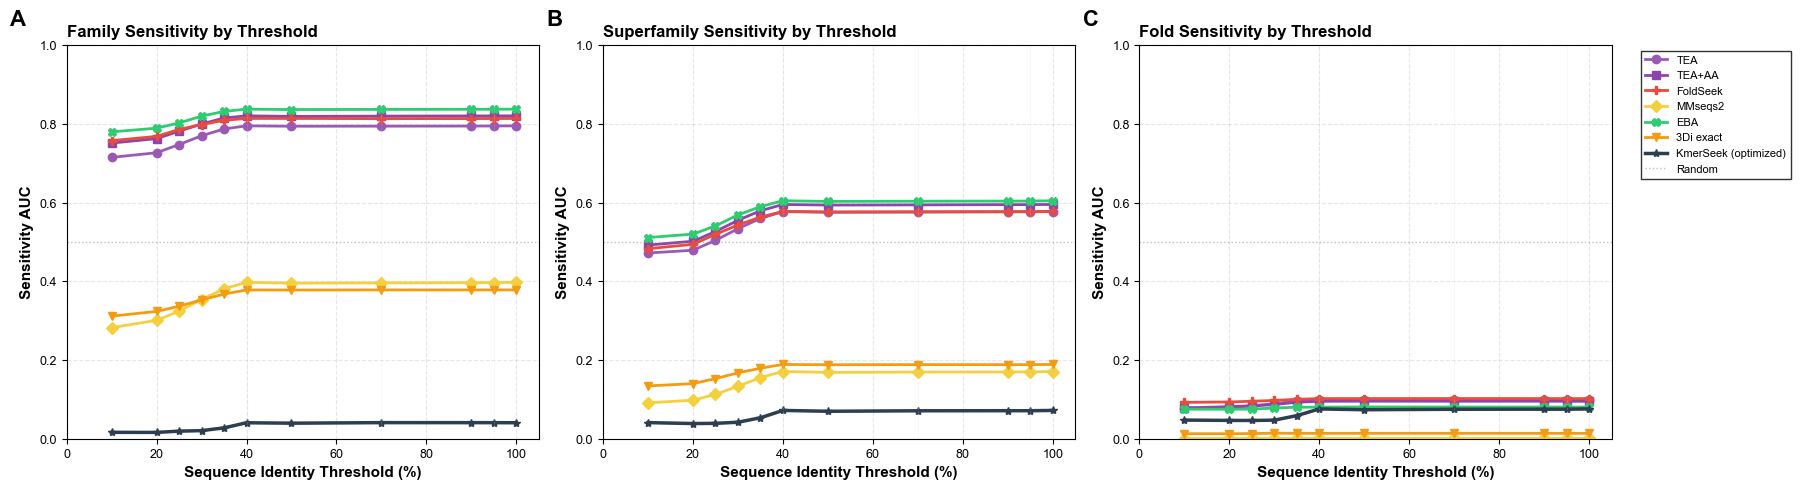

In [49]:
# Plot performance across thresholds - 3 panels for Family, Superfamily, Fold
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define colors for methods
method_colors = {
    'TEA': '#9B59B6',
    'TEA+AA': '#8E44AD',
    'FoldSeek': '#E74C3C',
    'MMseqs2': '#F4D03F',
    'EBA': '#2ECC71',
    '3Di exact': '#F39C12',
    'KmerSeek (BEST)': '#2C3E50',
    'KmerSeek (optimized)': '#2C3E50',
    'KmerSeek (TF-IDF)': '#3498DB',
}

method_markers = {
    'TEA': 'o',
    'TEA+AA': 's',
    'FoldSeek': 'P',
    'MMseqs2': 'D',
    'EBA': 'X',
    '3Di exact': 'v',
    'KmerSeek (BEST)': '*',
    'KmerSeek (optimized)': '*',
    'KmerSeek (TF-IDF)': '*',
}

for ax, level_name in zip(axes, ['Family', 'Superfamily', 'Fold']):
    level_data = results_df.filter(pl.col('level') == level_name)
    
    for method in methods_to_compare:
        if method not in tea_data:
            continue
        
        method_data = level_data.filter(pl.col('method') == method).sort('threshold')
        
        if len(method_data) == 0:
            continue
        
        thresholds = method_data['threshold'].to_list()
        aucs = method_data['auc'].to_list()
        
        color = method_colors.get(method, '#333333')
        marker = method_markers.get(method, 'o')
        
        linewidth = 2.5 if 'KmerSeek' in method else 2
        
        ax.plot(thresholds, aucs, '-', color=color, linewidth=linewidth,
                label=method, marker=marker, markersize=6)
    
    ax.set_xlabel('Sequence Identity Threshold (%)', fontweight='bold')
    ax.set_ylabel('Sensitivity AUC', fontweight='bold')
    ax.set_title(f'{level_name} Sensitivity by Threshold', fontweight='bold', loc='left')
    ax.set_xlim(0, 105)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Random')
    
    # Add vertical lines for interesting thresholds
    for th in [40, 70, 95]:
        ax.axvline(x=th, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.3)

# Add legend to last panel
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True,
               fancybox=False, edgecolor='black', fontsize=8)

# Add panel labels
for i, ax in enumerate(axes):
    ax.text(-0.12, 1.05, chr(65+i), transform=ax.transAxes,
            fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_by_threshold.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
# Create summary table showing performance at key thresholds
print("\nPerformance Summary at Key Sequence Identity Thresholds")
print("=" * 120)

# Focus on Superfamily and Fold (what you care about most)
for level_name in ['Superfamily', 'Fold']:
    print(f"\n{level_name} Level:")
    print("-" * 120)
    print(f"{'Method':<25} {'th_40':<10} {'th_70':<10} {'th_95':<10} {'Avg':<10} {'Relative to TEA':<20}")
    print("-" * 120)
    
    level_data = results_df.filter(pl.col('level') == level_name)
    
    # Get TEA baseline
    tea_baseline = {}
    for th in [40, 70, 95]:
        tea_row = level_data.filter((pl.col('method') == 'TEA') & (pl.col('threshold') == th))
        if len(tea_row) > 0:
            tea_baseline[th] = tea_row['auc'][0]
    
    for method in methods_to_compare:
        if method not in tea_data:
            continue
        
        aucs_at_th = {}
        for th in [40, 70, 95]:
            method_row = level_data.filter((pl.col('method') == method) & (pl.col('threshold') == th))
            if len(method_row) > 0:
                aucs_at_th[th] = method_row['auc'][0]
            else:
                aucs_at_th[th] = 0.0
        
        avg_auc = np.mean([aucs_at_th[40], aucs_at_th[70], aucs_at_th[95]])
        
        # Compute relative performance
        if len(tea_baseline) > 0:
            rel_perf = avg_auc / np.mean(list(tea_baseline.values()))
            rel_str = f"{rel_perf:.2%}"
        else:
            rel_str = "N/A"
        
        print(f"{method:<25} {aucs_at_th[40]:<10.4f} {aucs_at_th[70]:<10.4f} {aucs_at_th[95]:<10.4f} "
              f"{avg_auc:<10.4f} {rel_str:<20}")

print("\n" + "=" * 120)


Performance Summary at Key Sequence Identity Thresholds

Superfamily Level:
------------------------------------------------------------------------------------------------------------------------
Method                    th_40      th_70      th_95      Avg        Relative to TEA     
------------------------------------------------------------------------------------------------------------------------
TEA                       0.5772     0.5759     0.5767     0.5766     100.00%             
TEA+AA                    0.5954     0.5943     0.5950     0.5949     103.17%             
FoldSeek                  0.5777     0.5769     0.5772     0.5773     100.11%             
MMseqs2                   0.1708     0.1695     0.1700     0.1701     29.50%              
EBA                       0.6048     0.6037     0.6040     0.6041     104.77%             
3Di exact                 0.1888     0.1883     0.1883     0.1885     32.68%              
KmerSeek (optimized)      0.0719     0.0710 

In [51]:
# Analyze difficulty gradient: How does performance degrade as similarity decreases?
print("\nDifficulty Gradient Analysis")
print("=" * 100)
print("Showing how performance changes from high similarity (easy) to low similarity (hard)")
print()

for level_name in ['Superfamily', 'Fold']:
    print(f"\n{level_name}:")
    print(f"{'Method':<25} {'Easy (95%)':<12} {'Medium (40%)':<15} {'Hard (10%)':<12} {'Degradation':<15}")
    print("-" * 100)
    
    level_data = results_df.filter(pl.col('level') == level_name)
    
    for method in methods_to_compare:
        if method not in tea_data:
            continue
        
        aucs = {}
        for th in [10, 40, 95]:
            method_row = level_data.filter((pl.col('method') == method) & (pl.col('threshold') == th))
            if len(method_row) > 0:
                aucs[th] = method_row['auc'][0]
            else:
                aucs[th] = 0.0
        
        # Calculate degradation: how much worse at hard vs easy
        if aucs[95] > 0:
            degradation = (aucs[95] - aucs[10]) / aucs[95]
            degradation_str = f"{degradation:.1%}"
        else:
            degradation_str = "N/A"
        
        print(f"{method:<25} {aucs[95]:<12.4f} {aucs[40]:<15.4f} {aucs[10]:<12.4f} {degradation_str:<15}")

print("\n" + "=" * 100)
print("\nKey Insights:")
print("- Lower degradation = more robust to low sequence similarity")
print("- Methods with <50% degradation maintain performance even in hard cases")
print("- Methods with >80% degradation struggle with remote homology detection")


Difficulty Gradient Analysis
Showing how performance changes from high similarity (easy) to low similarity (hard)


Superfamily:
Method                    Easy (95%)   Medium (40%)    Hard (10%)   Degradation    
----------------------------------------------------------------------------------------------------
TEA                       0.5767       0.5772          0.4719       18.2%          
TEA+AA                    0.5950       0.5954          0.4922       17.3%          
FoldSeek                  0.5772       0.5777          0.4829       16.3%          
MMseqs2                   0.1700       0.1708          0.0912       46.3%          
EBA                       0.6040       0.6048          0.5113       15.4%          
3Di exact                 0.1883       0.1888          0.1342       28.7%          
KmerSeek (optimized)      0.0712       0.0719          0.0410       42.5%          

Fold:
Method                    Easy (95%)   Medium (40%)    Hard (10%)   Degradation    
------